In [1]:
"""
This code is based on the advection-diffusion example.
By removing the time derivative term, the advection term and add the u term, we obtain the PDE for a neumann problem. 
We use the Dirichlet boundary condition. 
Solver: 
    - Shallow neural network with fixed random weights.
    - We use the PINN loss, i.e., the least square loss. 
    - The resulting least square problem is solved by a direct learst square solver. 
2025 April 26: 
integration_weights, and integration_points, collocation points
2025 August 25: 
    - use a uniform grid to generate the collocation points. 
    - tanh activation function: working
    - changed the lstsq solver to scipy.linalg.lstsq 
2025 September 11:
    - add petrushev's scheme for generating nonlinear weights. 
"""
import torch
import torch.nn as nn
import itertools 
import numpy as np 
import math
import scipy 
import matplotlib.pyplot as plt

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(torch.float64)
import torch.nn.functional as F


ZERO = torch.tensor(0.0).to(device) 
pi = torch.tensor(np.pi).to(device) 



In [2]:

class ELMModel(nn.Module):
    def __init__(self, input_dim, M, activation, relu_k, Rm=0.1, remove_redundant=True, domain_choice=2):
        """
        Parameters:
            input_dim (int): Dimension of the input.
            M (int): Initial number of hidden neurons.
            activation (str): Activation function ('relu' or 'tanh').
            relu_k (int): For ReLU activation, the power to which it is raised.
            Rm (float): Range for weight and bias initialization.
            remove_redundant (bool): If True and using ReLU, remove redundant neurons.
            domain_choice (int): Choice for the domain points used in redundancy removal.
        """
        super(ELMModel, self).__init__()
        self.input_dim = input_dim
        self.M = M
        self.activation = activation
        self.k = relu_k
        
        # Define hidden-layer weights and biases as non-trainable parameters.
        self.W = nn.Parameter(torch.empty(M, input_dim).uniform_(-Rm, Rm), requires_grad=False)
        self.b = nn.Parameter(torch.empty(M).uniform_(-Rm, Rm), requires_grad=False)
        
        if self.activation == 'relu' and input_dim != 2:
            random_feature_sphere = torch.randn(M, input_dim + 1)
            random_feature_sphere = random_feature_sphere / torch.norm(random_feature_sphere, dim=1, keepdim=True)
            self.W.data = random_feature_sphere[:, :-1]
            self.b.data = random_feature_sphere[:, -1]
        if self.activation == 'relu' and input_dim == 2:
            neuron_nums = M
            indices = torch.arange(0, neuron_nums, dtype=torch.float) + 0.5
            phi = torch.acos(1 - 2*indices/neuron_nums)
            theta = pi * (1 + 5**0.5) * indices
            x = torch.sin(phi) * torch.cos(theta)
            y = torch.sin(phi) * torch.sin(theta)
            z = torch.cos(phi)
            points = torch.stack((x, y, z), dim=1)
            self.W.data[:,:] = points[:,0:2]
            self.b.data[:] = points[:,2]
        
        # Output weights φ
        self.phi = nn.Parameter(torch.zeros(1, M), requires_grad=False)
        
        if self.activation == 'relu' and remove_redundant:
            self.remove_redundant_neurons(dims=self.input_dim, choice=domain_choice)
    
    def hidden(self, x):
        if self.activation == 'tanh':
            return torch.tanh(x @ self.W.t() + self.b)
        elif self.activation == 'relu':
            return F.relu(x @ self.W.t() + self.b) ** self.k
            
    def forward(self, x):
        V = self.hidden(x)
        return V @ self.phi.t()
    
    def evaluate_derivative(self, x, i):
        if self.activation == 'tanh':
            fprime = 1 - torch.tanh(x @ self.W.t() + self.b) ** 2
            u1 = (fprime * self.W.t()[i-1:i, :]) @ self.phi.t()
        elif self.activation == 'relu':
            if self.k == 1:
                u1 = (torch.heaviside(x @ self.W.t() + self.b, torch.tensor(0.0)) * self.W.t()[i-1:i, :]) @ self.phi.t()
            else:
                u1 = (self.k * F.relu(x @ self.W.t() + self.b) ** (self.k - 1) * self.W.t()[i-1:i, :]) @ self.phi.t()
        return u1

    def remove_redundant_neurons(self, dims=3, choice=2):
        def create_mesh_grid(dims, pts):
            mesh = torch.tensor(list(itertools.product(pts, repeat=dims)), dtype=torch.float64)
            vertices = mesh.reshape(len(pts) ** dims, -1)
            return vertices
        
        if choice == 1:
            pts = torch.tensor([0., 1.])
        elif choice == 2:
            pts = torch.tensor([-1., 1.])
        elif choice == 3:
            pts = torch.tensor([-0.5, 0.5])
        else:
            raise ValueError("choice must be 1, 2, or 3")
        
        positions = create_mesh_grid(dims, pts)
        neuron_num = self.W.size(0)
        relu_k = self.k
        recorded_weights = []
        recorded_biases = []
        counter = 0
        poly_dofs = math.comb(relu_k + dims, dims)
        
        for i in range(neuron_num):
            w = self.W[i:i+1, :]
            b_val = self.b[i]
            values = positions @ w.t()
            left_end = - torch.max(values)
            right_end = - torch.min(values)
            offset = (right_end - left_end) / 50
            if b_val > left_end + offset/2 and b_val < right_end - offset/2:
                recorded_weights.append(w)
                recorded_biases.append(b_val)
            elif b_val >= right_end - offset/2 and counter < poly_dofs:
                recorded_weights.append(w)
                recorded_biases.append(b_val)
                counter += 1
        
        new_neuron_num = len(recorded_weights)
        if new_neuron_num == 0:
            print("Warning: No neurons selected; keeping all neurons.")
            return
        
        new_W = torch.cat(recorded_weights, dim=0)
        new_b = torch.stack(recorded_biases)
        self.M = new_neuron_num
        self.W = nn.Parameter(new_W, requires_grad=False)
        self.b = nn.Parameter(new_b, requires_grad=False)
        self.phi = nn.Parameter(torch.zeros(1, new_neuron_num), requires_grad=False)
        
        print("Number of neurons removed: ", neuron_num - new_neuron_num)
        print("Number of neurons left: ", new_neuron_num)

    def initialize_w_b_sphere(self,R_m):
        # generate a uniform grid on S^2 
        if self.input_dim == 2: 
            indices = torch.arange(0, self.M, dtype=torch.float) + 0.5
            phi = torch.acos(1 - 2*indices/self.M)
            theta = pi * (1 + 5**0.5) * indices
            x = torch.sin(phi) * torch.cos(theta)
            y = torch.sin(phi) * torch.sin(theta)
            z = torch.cos(phi)

            points = torch.stack((x, y, z), dim=1)
            self.W = nn.Parameter(points[:,0:2] * R_m, requires_grad=False)
            self.b = nn.Parameter(points[:,2] * R_m, requires_grad=False)

        elif self.input_dim == 1:
            theta = torch.linspace(0, pi, self.M+1)[:-1]
            w1 = torch.cos(theta) * R_m
            b = torch.sin(theta) * R_m
            self.W = nn.Parameter(w1[:].view(-1,1), requires_grad=False)
            self.b = nn.Parameter(b[:], requires_grad=False)
        else: 
            w_b = torch.randn(self.M ,self.input_dim + 1) 
            w_b = w_b / torch.norm(w_b,dim=1).view(-1,1) 
            w_b = w_b * R_m 
            self.W = nn.Parameter(w_b[:,:-1], requires_grad=False)
            self.b = nn.Parameter(w_b[:,-1], requires_grad=False) 

    def initialize_w_b_uniform_deterministic(self, R_m):
        """
        Uniform and deterministic initialization for tanh ELMs.
        """
        if self.activation != "tanh":
            raise ValueError("initialize_w_b_uniform_deterministic() is intended for activation == 'tanh'.")

        x_grid = torch.linspace(-R_m, R_m, int(math.ceil(self.M ** (1 / (self.input_dim+1)))), device=self.W.device) # [:-1]
        if self.input_dim == 1:
            #2d grid 

            # h_half = (x_grid[1]-x_grid[0])/2 
            x_grid_shifted = x_grid # + h_half 
            x,y = torch.meshgrid(x_grid, x_grid_shifted, indexing='ij')
            weights = x.flatten().view(-1,1)
            biases = y.flatten()
        elif self.input_dim == 2:
            #3d grid 
            h_third = (x_grid[1]-x_grid[0])/3
            x_grid_shifted = x_grid #+ h_third
            x_grid_shifted2 = x_grid # + 2*h_third
            x,y,z = torch.meshgrid(x_grid, x_grid_shifted, x_grid_shifted2, indexing='ij')
            weights = torch.stack((x.flatten(),y.flatten()),dim=1)
            biases = z.flatten()
        else:
            # quasi monte carlo points
            raise NotImplementedError("Quasi Monte Carlo points not implemented.")

        new_M = weights.shape[0]

        with torch.no_grad():
            self.W = nn.Parameter(weights, requires_grad=False)
            self.b = nn.Parameter(biases, requires_grad=False)
            self.M = new_M
            self.phi = nn.Parameter(torch.zeros(1, new_M, device=device), requires_grad=False)

        return self

    def initialize_w_b_petrushev(self, R_m, scale=1):
        """
        Petrushev-style tensor-product initialization for tanh ELMs.
        """
        if self.activation != "tanh":
            raise ValueError("initialize_w_b_petrushev() is intended for activation == 'tanh'.")

        device = self.W.device
        in_feats = self.input_dim
        out_feats = self.M

        n1 = int(scale * math.ceil(out_feats ** ((in_feats - 1) / in_feats)))
        n2 = int(math.ceil(out_feats ** (1 / in_feats)))

        if in_feats == 1:
            weights = torch.ones(n1, 1, device=device)
        elif in_feats == 2:
            weights = torch.zeros(n1, 2, device=device)
            theta = torch.tensor(np.linspace(0, math.pi, n1, endpoint=False), device=device, dtype=weights.dtype)
            weights[:, 0] = torch.cos(theta)
            weights[:, 1] = torch.sin(theta)
        elif in_feats == 3:
            indices = torch.arange(0, n1, dtype=torch.float32, device=device) + 0.5
            phi = torch.acos(1 - 2 * indices / n1)
            theta = math.pi * (1 + 5 ** 0.5) * indices
            x = torch.sin(phi) * torch.cos(theta)
            y = torch.sin(phi) * torch.sin(theta)
            z = torch.cos(phi)
            weights = torch.stack((x, y, z), dim=1)
        else:
            weights = torch.randn(n1, in_feats, device=device)
            weights = weights / (weights.norm(dim=1, keepdim=True) + 1e-12)

        weights = torch.tile(weights, (1, n2)).reshape(-1, in_feats)

        biases = torch.linspace(-R_m, R_m, n2, device=device)
        biases = torch.tile(biases, (n1,)).reshape(-1)

        new_M = weights.shape[0]

        with torch.no_grad():
            self.W = nn.Parameter(weights, requires_grad=False)
            self.b = nn.Parameter(biases, requires_grad=False)
            self.M = new_M
            self.phi = nn.Parameter(torch.zeros(1, new_M, device=device), requires_grad=False)

        return self

def plot_2D(f): 
    
    Nx = 200
    Ny = 200 
    xs = np.linspace(-1, 1, Nx)
    ys = np.linspace(-1, 1, Ny)
    x, y = np.meshgrid(xs, ys, indexing='xy')
    xy_comb = np.stack((x.flatten(),y.flatten())).T
    xy_comb = torch.tensor(xy_comb)
    z = f(xy_comb).reshape(Nx,Ny)
    z = z.detach().numpy()
    plt.figure(dpi=200)
    ax = plt.axes(projection='3d')
    ax.plot_surface(x , y , z )

    plt.show()

In [3]:
R_m = 2 
M = 9 
input_dim = 2 
x_grid = torch.linspace(-R_m, R_m, int(math.ceil(M ** (1 / (input_dim+1)))))[:-1]
h_half = (x_grid[1]-x_grid[0])/2 
x_grid_shifted = x_grid + h_half 
print(x_grid) 
    #2d grid 
x,y,z = torch.meshgrid(x_grid, x_grid, x_grid, indexing='ij')
weights = torch.stack((x.flatten(),y.flatten()),dim=1)
biases = z.flatten()

weights, biases 

tensor([-2.,  0.])


(tensor([[-2., -2.],
         [-2., -2.],
         [-2.,  0.],
         [-2.,  0.],
         [ 0., -2.],
         [ 0., -2.],
         [ 0.,  0.],
         [ 0.,  0.]]),
 tensor([-2.,  0., -2.,  0., -2.,  0., -2.,  0.]))

## Neumann Problem with Dirichlet boundary condition revising...
1. Change the monte carlo collocation points to gaussian quadrature collocation points with weights 
2. Change the error evalution to gaussian quadrature for dimension less than or equal to 3. 
3. Print the convergence order more clearly.  

In [4]:

# ---------------------------
# Optiion 2: Exact solution and forcing function 
# ---------------------------
# def u_exact(x, d):
#     # x: (N, d+1) with the last column being t
#     s = x[:, :d].sum(dim=1, keepdim=True) / d
#     # t = x[:, -1:]
#     return torch.sin(2 * s)  # * torch.exp(-t / d)

# def u_exact_grad(d):
#     def make_grad_i(i,d):
#         def grad_i(x):
#             s = x[:, :d].sum(dim=1, keepdim=True) / d
#             # t = x[:, -1:]
#             return 2 * torch.cos(2 * s) / d
#         return grad_i 
    
#     u_grad=[] 
#     for i in range(d):
#         u_grad.append(make_grad_i(i,d))
#     return u_grad

# def f_rhs(x, d):
#     # Forcing term computed so that u_exact is the solution.
#     s = x[:, :d].sum(dim=1, keepdim=True) / d
#     # t = x[:, -1:]
#     return (4.0 / d) * torch.sin(2 * s) + u_exact(x, d)  # * torch.exp(-t / d)

def generate_initial_points(N, d,x_l = 0 ,x_r =1): # intial points are interior points 
    # Samples N points uniformly in Ω at t = 0 (initial condition)
    X = torch.empty(N, d).uniform_(x_l, x_r)
    # t = torch.zeros(N, 1)
    # return torch.cat([X, t], dim=1).to(device)
    return X.to(device) 

def generate_boundary_points(N_bc, d,x_l = 0,x_r = 1):
    # For each spatial coordinate, for both faces (x_i = -1 and x_i = 1)
    # sample N_bc points (with random values in the remaining coordinates and t ∈ [0,T])
    points_list = []
    for i in range(d):
        for val in [x_l, x_r]:
            X = torch.empty(N_bc, d).uniform_(x_l, x_r)
            X[:, i] = val  # set the i-th coordinate to the boundary value
            # t = torch.empty(N_bc, 1).uniform_(0, T)
            # pts = torch.cat([X, t], dim=1)
            points_list.append(X)
    return torch.cat(points_list, dim=0).to(device)

def MonteCarlo_Sobol_dDim_weights_points(M ,d = 4,bl = -1,ur = 1):    
    length = ur - bl
    vol = length ** d 
    Sob_integral = torch.quasirandom.SobolEngine(dimension =d, scramble= False, seed=None) 
    integration_points = Sob_integral.draw(M).double() 
    integration_points = integration_points.to(device) * (length) - length/2
    weights = torch.ones(M,1).to(device)/M * vol 
    return weights.to(device), integration_points.to(device) 

def PiecewiseGQ1D_weights_points(x_l,x_r,Nx, order):
    """ Output the coeffients and weights for piecewise Gauss Quadrature 
    Parameters
    ----------
    x_l : float 
    left endpoint of an interval 
    
    x_r: float
    right endpoint of an interval 
    
    integration_intervals: int
    number of subintervals for integration
    
    Returns
    -------
    coef1_expand
    
    gw_expand
    
    integration_points
    """
    x,w = np.polynomial.legendre.leggauss(order)
    gx = torch.tensor(x).to(device)
    gx = gx.view(1,-1) # row vector 
    gw = torch.tensor(w).to(device)    
    gw = gw.view(-1,1) # Column vector 
    nodes = torch.linspace(x_l,x_r,Nx+1).view(-1,1).to(device) 
    coef1 = ((nodes[1:,:] - nodes[:-1,:])/2) # n by 1  
    coef2 = ((nodes[1:,:] + nodes[:-1,:])/2) # n by 1  
    coef2_expand = coef2.expand(-1,gx.size(1)) # Expand to n by p shape, -1: keep the first dimension n , expand the 2nd dim (columns)
    integration_points = coef1@gx + coef2_expand
    integration_points = integration_points.flatten().view(-1,1) # Make it a column vector
    gw_expand = torch.tile(gw,(Nx,1)) # rows: n copies of current tensor, columns: 1 copy, no change
    # Modify coef1 to be compatible with func_values
    coef1_expand = coef1.expand(coef1.size(0),gx.size(1))    
    coef1_expand = coef1_expand.flatten().view(-1,1)

    return coef1_expand.to(device)*gw_expand.to(device), integration_points.to(device)


def PiecewiseGQ2D_weights_points(Nx, order,l_point = (-1,-1), r_point = (1,1)): 
    """ A slight modification of PiecewiseGQ2D function that only needs the weights and integration points.
    Parameters. 
    Only works for the square domain centered at origin or with the left point at origin.
    ----------
    Nx: int 
        number of intervals along the dimension. No Ny, assume Nx = Ny
    order: int 
        order of the Gauss Quadrature
    l_point: (x1,x2)
        left bottom point of the rectangular domain 
    r_point: (x1,x2)
        right top point of the rectangular domain 

    Returns
    -------
    long_weights: torch.tensor
    integration_points: torch.tensor
    """
    assert Nx%2==0, "Nx should be even" 

    h1 = (r_point[0] - l_point[0])/Nx
    h2 = (r_point[1] - l_point[1])/Nx 

    x, w = np.polynomial.legendre.leggauss(order)
    gauss_pts = np.array(np.meshgrid(x,x,indexing='ij')).reshape(2,-1).T
    weights =  (w*w[:,None]).ravel()

    gauss_pts =torch.tensor(gauss_pts)
    weights = torch.tensor(weights)

    long_weights =  torch.tile(weights,(Nx**2,1))
    long_weights = long_weights.reshape(-1,1)
    long_weights = long_weights * (h1/2) * (h2/2) # scale the weights  
    integration_points = torch.tile(gauss_pts,(Nx**2,1))
    scale_factor = h1/2 
    integration_points = scale_factor * integration_points

    offset = 0 if l_point[0] == 0 else 1 

    index = np.arange(1,Nx+1)- (Nx/2)*offset - 0.5 
    ordered_pairs = np.array(np.meshgrid(index,index,indexing='ij'))
    ordered_pairs = ordered_pairs.reshape(2,-1).T
    ordered_pairs = torch.tensor(ordered_pairs)
    ordered_pairs = torch.tile(ordered_pairs, (1,order**2)) # number of GQ points
    ordered_pairs =  ordered_pairs.reshape(-1,2)

    translation = ordered_pairs*h1
    integration_points = integration_points + translation 
    return long_weights, integration_points

def PiecewiseGQ3D_weights_points(Nx, order,bl = [-1,-1,-1],ur = [1,1,1]): 
    """ A slight modification of PiecewiseGQ2D function that only needs the weights and integration points.
    Parameters
    ----------

    Nx: int 
        number of intervals along the dimension. No Ny, assume Nx = Ny
    order: int 
        order of the Gauss Quadrature

    Returns
    -------
    long_weights: torch.tensor
    integration_points: torch.tensor
    """

    """
    Parameters
    ----------
    target : 
        Target function 
    Nx: int 
        number of intervals along the dimension. No Ny, assume Nx = Ny
    order: int 
        order of the Gauss Quadrature
    """

    # print("order: ",order )
    x, w = np.polynomial.legendre.leggauss(order)
    gauss_pts = np.array(np.meshgrid(x,x,x,indexing='ij')).reshape(3,-1).T
    weight_list = np.array(np.meshgrid(w,w,w,indexing='ij'))
    weights =   (weight_list[0]*weight_list[1]*weight_list[2]).ravel() 

    gauss_pts =torch.tensor(gauss_pts)
    weights = torch.tensor(weights)

    # h = 1/Nx # 100 intervals 
    h = (ur[0]- bl[0])/Nx # 100 intervals 
    long_weights =  torch.tile(weights,(Nx**3,1))
    long_weights = long_weights.reshape(-1,1)
    long_weights = long_weights * h**3 /8 

    integration_points = torch.tile(gauss_pts,(Nx**3,1))
    # print("shape of integration_points", integration_points.size())
    scale_factor = h/2 
    integration_points = scale_factor * integration_points

    # index = np.arange(1,Nx+1)-0.5
    index = np.arange(0,Nx)  
    ordered_pairs = np.array(np.meshgrid(index,index,index,indexing='ij'))
    ordered_pairs = ordered_pairs.reshape(3,-1).T

    # print(ordered_pairs)
    # print()
    ordered_pairs = torch.tensor(ordered_pairs)
    # print(ordered_pairs.size())
    ordered_pairs = torch.tile(ordered_pairs, (1,order**3)) # number of GQ points
    # print(ordered_pairs)

    ordered_pairs =  ordered_pairs.reshape(-1,3)
    # print(ordered_pairs)
    # translation = ordered_pairs*h 
    translation = ordered_pairs*h + (torch.tensor(bl) + h/2) 
    # print(translation)

    integration_points = integration_points + translation 

    return long_weights.to(device), integration_points.to(device)





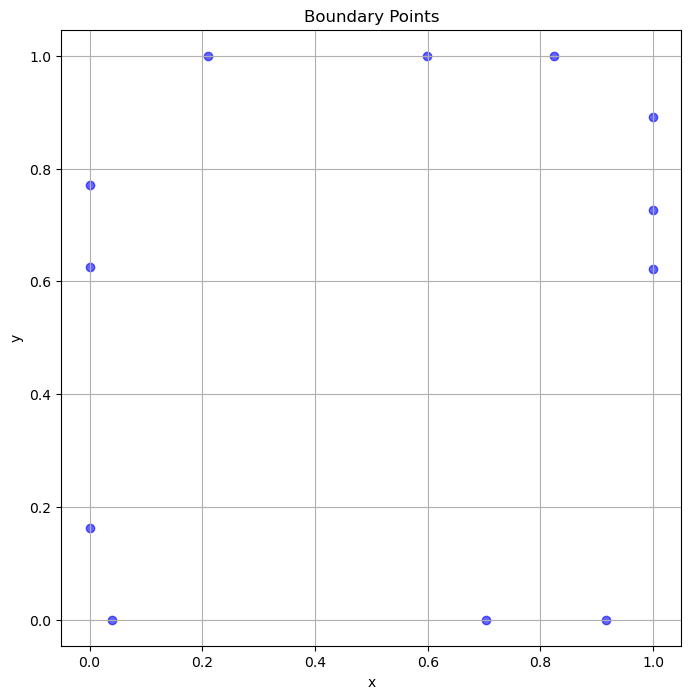

In [5]:
def generate_boundary_points(N_bc, d,x_l = 0,x_r = 1):
    # For each spatial coordinate, for both faces (x_i = -1 and x_i = 1)
    # sample N_bc points (with random values in the remaining coordinates and t ∈ [0,T])
    points_list = []
    for i in range(d):
        for val in [x_l, x_r]:
            X = torch.empty(N_bc, d).uniform_(x_l, x_r)
            X[:, i] = val  # set the i-th coordinate to the boundary value
            # t = torch.empty(N_bc, 1).uniform_(0, T)
            # pts = torch.cat([X, t], dim=1)
            points_list.append(X)
    return torch.cat(points_list, dim=0).to(device)

N_bc = 3 
d = 2 

boundary_pts = generate_boundary_points(N_bc,d)

plt.figure(figsize=(8,8))
plt.scatter(boundary_pts[:,0], boundary_pts[:,1], c='blue', alpha=0.6)
plt.grid(True)
plt.xlabel('x')
plt.ylabel('y') 
plt.title('Boundary Points',fontsize=12)
plt.axis('equal')
plt.show()






## Assemble matrix 

In [6]:

# ---------------------------
# Compute derivatives for the PDE residual
# ---------------------------
def compute_design_matrix_interior_manual(integration_weights, x, model, d):
    """
    Manually computes the design matrix for interior collocation points,
    assuming the hidden-layer activation is tanh.
    
    Parameters:
      x: Tensor of shape (N, d+1) representing interior collocation points.
         The first d columns are spatial coordinates and the last column is time.
      model: A model object that has fixed parameters model.W and model.b.
             model.W is of shape (M, d+1) and model.b is of shape (M,).
      d: Number of spatial dimensions.
      
    Returns:
      A_in: The design matrix of shape (N, M) where each entry is given by
            A_in = (∂_t V - Δ V + R·∇_x V) computed analytically.
      V: The hidden layer outputs (tanh(Z)) detached from the graph.
    """
    # Retrieve fixed parameters from the model.
    # model.W is assumed to have shape (M, d+1) and model.b has shape (M,)
    W = model.W  # shape: (M, d+1)
    b = model.b  # shape: (M,)
    activation = model.activation
    relu_k = model.k # power of the activation function 
    # Compute Z = x @ W^T + b.
    # x: (N, d+1), W^T: (d+1, M), result Z: (N, M)
    
    Z = x @ W.t() + b  # shape: (N, M)
    
    # Activation function: tanh.
    if activation == 'tanh': 
        V = torch.tanh(Z)
        fprime = 1 - V**2         # shape: (N, M)
        fsecond = -2 * V * fprime   # shape: (N, M)
    elif activation == 'relu' and relu_k != 2:
        V = F.relu(Z)**relu_k
        fprime = relu_k * F.relu(Z)**(relu_k-1) # 1 - V**2         # shape: (N, M)
        fsecond = relu_k * (relu_k - 1) * F.relu(Z)**(relu_k-2) # -2 * V * fprime   # shape: (N, M)
    elif activation == 'relu' and relu_k == 2: 
        V = F.relu(Z)**relu_k
        fprime = relu_k * F.relu(Z)**(relu_k-1) # 1 - V**2         # shape: (N, M) 
        fsecond = relu_k * (relu_k - 1) * torch.heaviside(Z,ZERO) # -2 * V * fprime   # shape: (N, M)

    # ---------------------------
    # Laplacian Δ V: sum_{i=1}^{d} ∂^2 V / ∂x_i^2.
    # For a fixed hidden unit j, note that:
    #   ∂^2 V_j/∂x_i^2 = f''(Z) * (W[j,i])^2.
    # Thus, for each hidden unit j, the Laplacian is:
    #   laplacian_V = fsecond * sum_{i=1}^{d} (W[j,i])^2.
    W_spatial_sq = W[:, :d]**2         # shape: (M, d)
    laplacian_per_unit = W_spatial_sq.sum(dim=1)  # shape: (M,)
    laplacian_V = fsecond * laplacian_per_unit.unsqueeze(0)  # shape: (N, M), unsqueezed for broadcasting, after unsqueezing(1,M)
    

    # ---------------------------
    # Combine to form the design matrix for the PDE:
    # For the advection-diffusion equation, the residual is:
    #   ∂_t u - Δ u + R·∇ u = f.
    # Since u = V φ, the design matrix is:
    #   A_in = (∂_t V - Δ V + R·∇ V)
    # A_in = dV_dt - laplacian_V + R_dot_grad  # shape: (N, M)
    A_in = - laplacian_V # + V.detach()  # shape: (N, M)
    
    return A_in * integration_weights, V.detach()

def compute_design_matrix_boundary(x, model):
    # For boundary (and initial) collocation points, the design matrix is just V.
    V = model.hidden(x)
    return V

def compute_normal_equation_interior(x,model,d):
    # Retrieve fixed parameters from the model.
    # model.W is assumed to have shape (M, d+1) and model.b has shape (M,)
    W = model.W  # shape: (M, d+1)
    b = model.b  # shape: (M,)
    n = b.size(0) # number of neurons 
    activation = model.activation
    relu_k = model.k # power of the activation function 
    
    # store the matrix and the vector 
    A_normal = torch.zeros(n,n).to(device)
    b_normal = torch.zeros(n,1).to(device)
    
    # Compute Z = x @ W^T + b.
    # x: (M, d+1), W^T: (d+1, n), result Z: (M, n)
    batch_size = 10000 
    M = x.size(0) # number of data points 
    for j in range(0,M,batch_size):
        end_index = j + batch_size

    
        Z = x[j : end_index,:] @ W.t() + b  # shape: (batch_size, n)
        f_in_batch = f_rhs(x[j:end_index,:], d) 
        
        # Activation function: tanh.
        if activation == 'tanh': 
            V = torch.tanh(Z)
            fprime = 1 - V**2         # shape: (batch_size, n)
            fsecond = -2 * V * fprime   # shape: (batch_size, n)
        elif activation == 'relu':
            V = F.relu(Z)**relu_k
            fprime = relu_k * F.relu(Z)**(relu_k-1) # 1 - V**2         # shape: (batch_size, n)
            fsecond = relu_k * (relu_k - 1) * F.relu(Z)**(relu_k-2) # -2 * V * fprime   # shape: (batch_size, n)

        # ---------------------------
        # Laplacian Δ V: sum_{i=1}^{d} ∂^2 V / ∂x_i^2.
        # For a fixed hidden unit j, note that:
        #   ∂^2 V_j/∂x_i^2 = f''(Z) * (W[j,i])^2.
        # Thus, for each hidden unit j, the Laplacian is:
        #   laplacian_V = fsecond * sum_{i=1}^{d} (W[j,i])^2.
        W_spatial_sq = W[:, :d]**2         # shape: (n, d)
        laplacian_per_unit = W_spatial_sq.sum(dim=1)  # shape: (n,)
        laplacian_V = fsecond * laplacian_per_unit.unsqueeze(0)  # shape: (batch_size, n), unsqueezed for broadcasting, after unsqueezing(1,M)

        A_in_batch = - laplacian_V  # + V.detach()  # shape: (batch_size, n)
        A_normal[:,:] += A_in_batch.t() @ A_in_batch 
        b_normal[:,:] += A_in_batch.t() @ f_in_batch
        
    return A_normal, b_normal

def compute_normal_equation_bc(x_bc,model,d):
    # Retrieve fixed parameters from the model.
    # model.W is assumed to have shape (M, d+1) and model.b has shape (M,)
    W = model.W  # shape: (M, d+1)
    b = model.b  # shape: (M,)
    n = b.size(0) # number of neurons 
    activation = model.activation
    relu_k = model.k # power of the activation function 
    
    # store the matrix and the vector 
    A_normal = torch.zeros(n,n).to(device)
    b_normal = torch.zeros(n,1).to(device)
    
    # Compute Z = x @ W^T + b.
    # x: (M, d+1), W^T: (d+1, n), result Z: (M, n)
    batch_size = 10000 
    M = x_bc.size(0) # number of data points 
    for j in range(0,M,batch_size):
        end_index = j + batch_size

    
        V_batch = model.hidden(x_bc[j : end_index,:])
        g_bc_batch = u_exact(x_bc[j : end_index,:], d)
        A_normal[:,:] = V_batch.t() @ V_batch 
        b_normal[:,:] = V_batch.t() @ g_bc_batch
        
    return A_normal, b_normal 



In [7]:
def rescale_mat_rhs(A,f):
    c = 100.0
    for i in range(len(A)):
        ## change 
        max_a = abs(A[i,:]).max()
        max_b = A[i,:].max()
        if max_a != max_b: 
            ratio = -c/max_a
            A[i,:] = A[i,:]*ratio
            f[i] = f[i]*ratio
        else: 
            ratio = c/max_a
            A[i,:] = A[i,:]*ratio
            f[i] = f[i]*ratio
    return A,f 

## 1D 

Activation: tanh, relu_k: 3, Rm: 1
L2 error 3.312747e-07; H1 error 3.986974e-07 
L2 norm of u 1.2247448713915905; H1 norm of u 10.179923683969262 

thoeretical orders L^2: 4.0, H1: 3.0 
Convergence orders (mc error L2): tensor([ 5.6265, 15.6321,  4.7285, -0.1256,  1.6546,  0.9638])
Convergence orders (mc error H1): tensor([ 5.5140, 13.3484, 10.6151, -1.4200,  1.5826,  0.3106])
Activation: tanh, relu_k: 3, Rm: 2
L2 error 7.851220e-11; H1 error 2.622478e-10 
L2 norm of u 1.2247448713915905; H1 norm of u 10.179923683969262 

thoeretical orders L^2: 4.0, H1: 3.0 
Convergence orders (mc error L2): tensor([ 2.1249, 15.5023, 14.4658,  4.5617, -0.8042,  2.6747])
Convergence orders (mc error H1): tensor([ 2.1247, 14.2916, 17.4200,  2.8385,  1.7948,  0.1102])
Activation: tanh, relu_k: 3, Rm: 4
L2 error 3.975387e-13; H1 error 1.113997e-13 
L2 norm of u 1.2247448713915905; H1 norm of u 10.179923683969262 

thoeretical orders L^2: 4.0, H1: 3.0 
Convergence orders (mc error L2): tensor([-0.8775, 15.

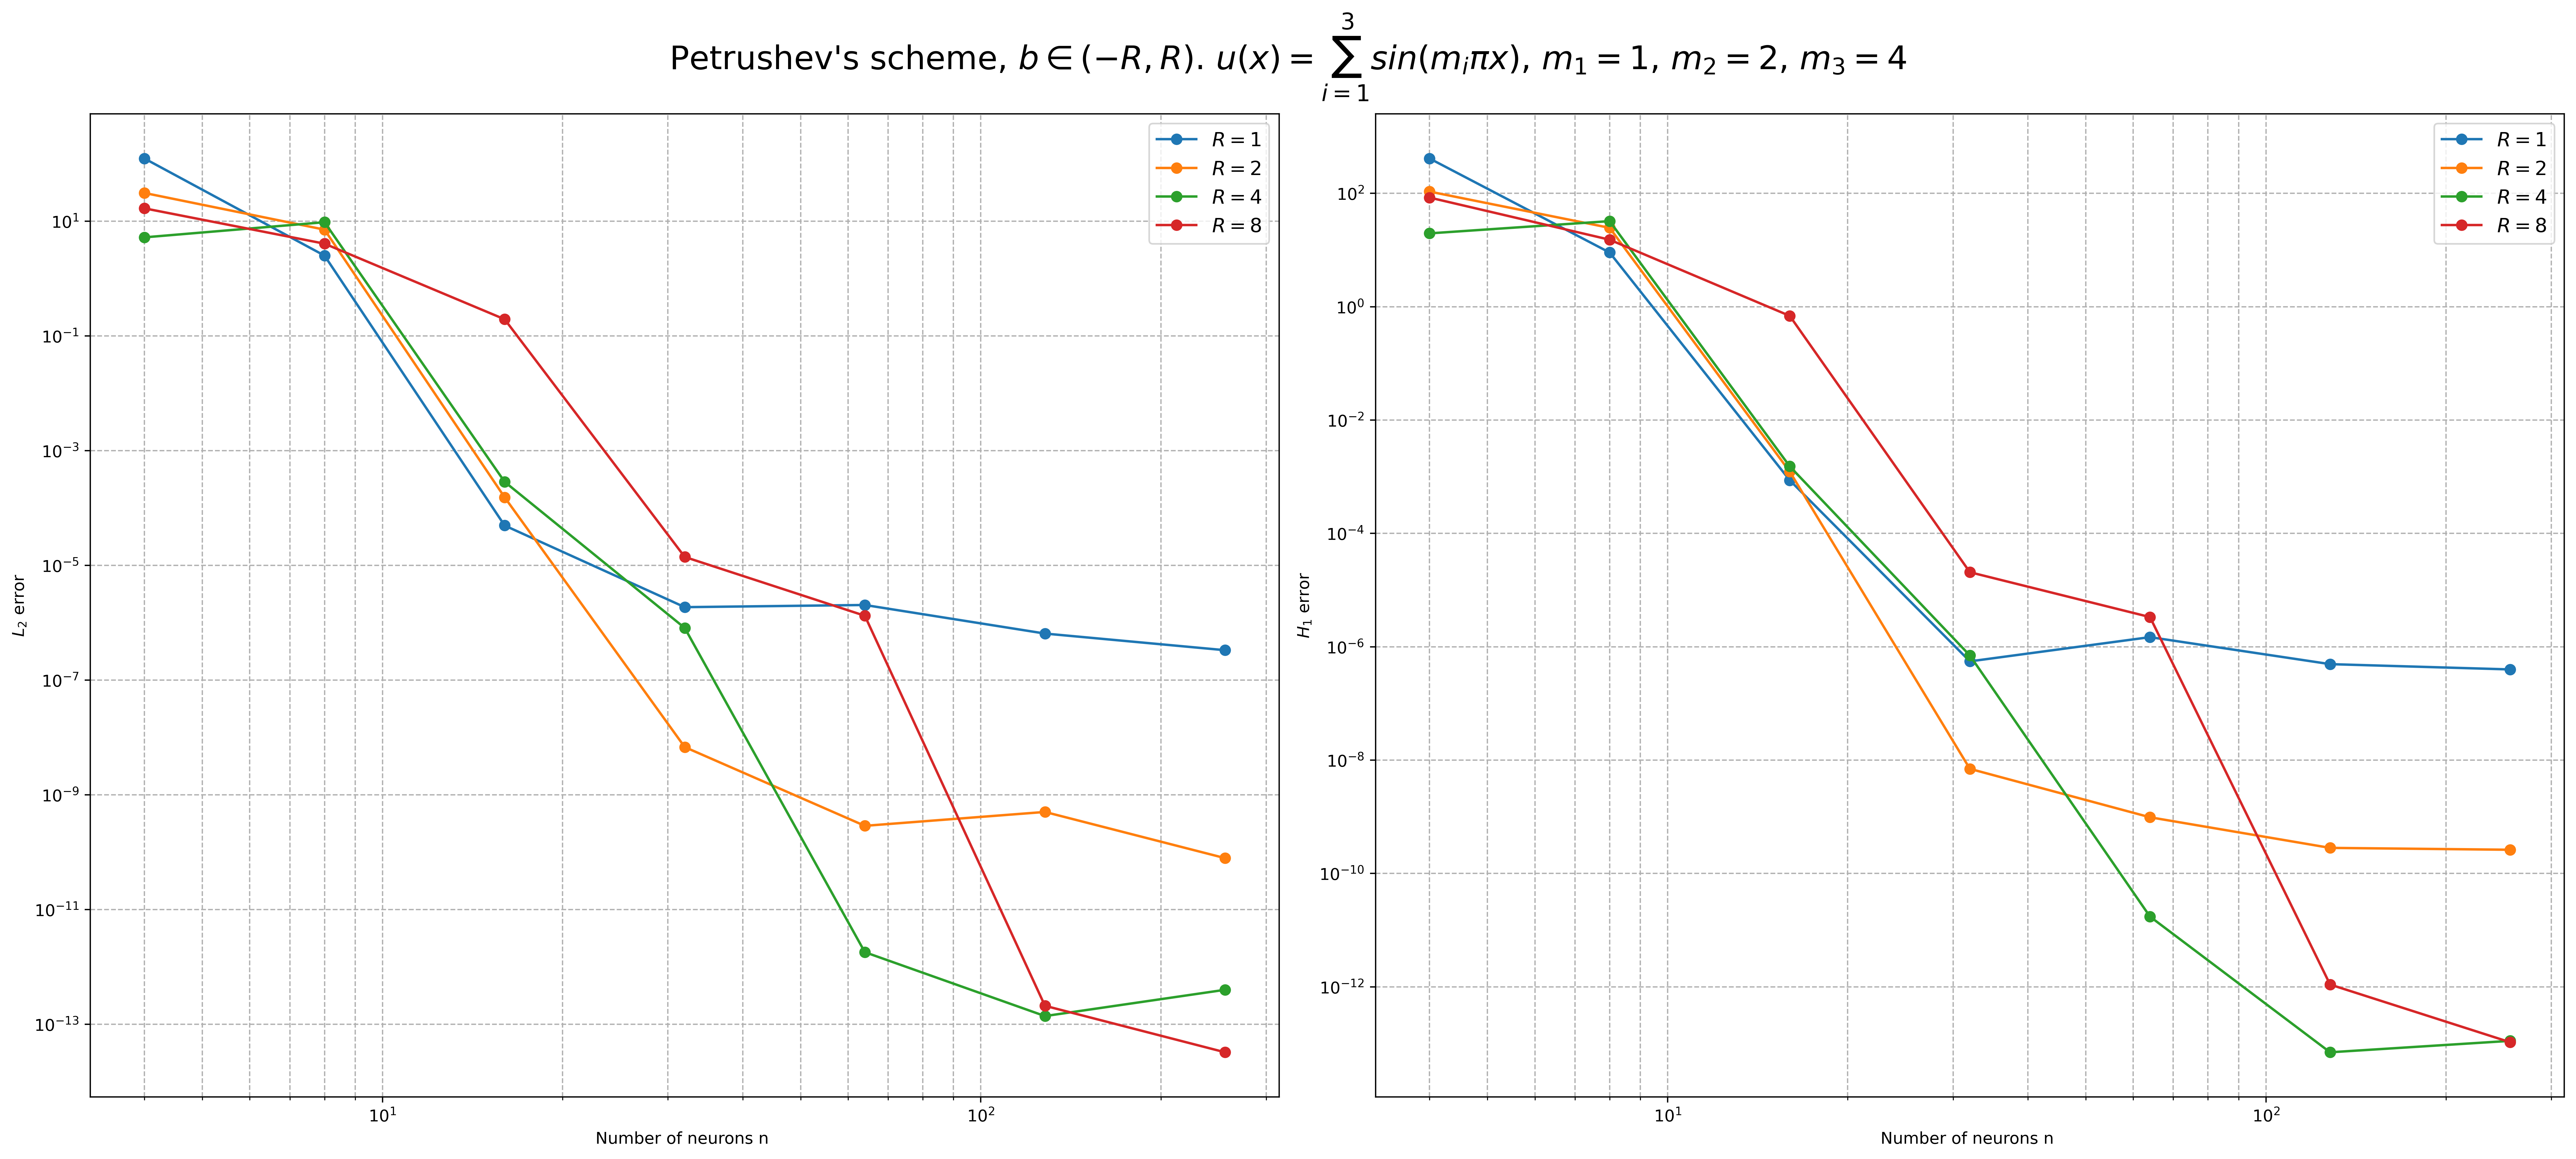

In [8]:
    
# ---------------------------
# Main routine
# ---------------------------

# ---------------------------
# Optiion 1: Exact solution and forcing function 
# ---------------------------


def main(m1,m2,m3):

    def u_exact(x,d):
        z1 = torch.prod(torch.sin(m1 * pi * x),dim = 1,keepdim = True)
        z2 = torch.prod(torch.sin(m2 * pi * x),dim = 1,keepdim = True) 
        z3 = torch.prod(torch.sin(m3 * pi * x),dim = 1,keepdim = True) 
        return z1 + z2 + z3 

    def f_rhs(x,d):
        z1 = (d * (m1 * pi)**2 )*torch.prod(torch.sin(m1 * pi * x),dim = 1,keepdim = True) 
        z2 = (d * (m2 * pi)**2 )*torch.prod(torch.sin(m2 * pi * x),dim = 1,keepdim = True)
        z3 = (d * (m3 * pi)**2 )*torch.prod(torch.sin(m3 * pi * x),dim = 1,keepdim = True)
        z = z1 + z2 + z3
        return z

    def u_exact_grad(d):
        dim = d # d is global variable defined outside the function 
        grad_list = [] 
        def make_u_i(i):
            def u_i(x): 
                sin_terms = torch.sin(m1 * pi * x)
                cos_term = torch.cos(m1 * pi * x[:, i-1:i])
                sin_terms[:, i-1:i] = cos_term  # Replace the first sine term with the cosine term
                z1 = (m1 * pi) * torch.prod(sin_terms, dim=1, keepdim=True)

                sin_terms = torch.sin(m2 * pi * x)
                cos_term = torch.cos(m2 * pi * x[:, i-1:i])
                sin_terms[:, i-1:i] = cos_term  # Replace the first sine term
                z2 = (m2 * pi) * torch.prod(sin_terms, dim=1, keepdim=True)

                sin_terms = torch.sin(m3 * pi * x)
                cos_term = torch.cos(m3 * pi * x[:, i-1:i])
                sin_terms[:, i-1:i] = cos_term  # Replace the first sine term
                z3 = (m3 * pi) * torch.prod(sin_terms, dim=1, keepdim=True)
                z = z1 + z2 + z3
                return z 
            
            return u_i 
        for i in range(1,dim+1):
            grad_list.append(make_u_i(i))
        return grad_list

    # torch.manual_seed(1)
    # Problem and network parameters:
    d = 1         # spatial dimension (you can change this to, say, 10)
    input_dim = d # spatial
    activation = 'tanh'
    relu_k = 3 #if activation is tanh, this parameter is not used
    # neuron_list = [16,32,64,128,256] # 250,500,1000,2000,4000,8000]
    # neuron_list = [i for i in range(4,50,4)] 
    neuron_list = [2**i for i in range(2,9)]
    actual_neuron_list = torch.zeros(len(neuron_list))

    errors_l2 = torch.zeros(len(neuron_list))
    Nx = 1024 
    order = 5 
    x_l, x_r = 0, 1
    integration_weights, integration_points = PiecewiseGQ1D_weights_points(x_l,x_r,Nx,order)
    fig, axes = plt.subplots(1, 2, figsize=(11*2, 10), dpi=400)  
    for Rm in [1,2,4,8]: # 1e-2,5e-2,1e-1,5e-1,1,2,4 
        print('Activation: {}, relu_k: {}, Rm: {}'.format(activation,relu_k,Rm))
        trial_num = 1 
        errors_l2_trials = torch.zeros(trial_num, len(neuron_list)) 
        errors_h1_trials = torch.zeros(trial_num, len(neuron_list)) 
        for i, n in enumerate(neuron_list): # number of hidden units in the ELM

            for trial in range(trial_num):  
                
                # Number of collocation points
                N_bc = 1 #int(0.2 * n**1.5) # 160       # per boundary face (for Dirichlet BC)
                N_init = 4000 #int( 4 * n**1.5) # 1000    # initial condition points (at t = 0)
                # print("boundary points: ",N_bc*2*d)
                # print("interior points: ",N_init) 
                # print("total points: ",N_bc*2*d + N_init)
                # Generate collocation points:
                X_bc = generate_boundary_points(N_bc, d,x_l,x_r)     # boundary points on ∂Ω × [0, T]
                X_init = generate_initial_points(N_init, d,x_l,x_r)     # initial points: Ω at t = 0
                # X_init = integration_points
                integration_weights = torch.ones(X_init.size(), device=device)
                # Compute the right-hand side f (for the PDE) at interior points:
                f_in = f_rhs(X_init, d)   # shape: (N_in, 1)
                # For Dirichlet boundary condition, g(x, t) is given by u_exact:
                g_bc = u_exact(X_bc, d)
                # For initial condition, h(x) = u_exact(x, 0):

                # Create the ELM model:
                model = ELMModel(input_dim, n, activation, relu_k, Rm).to(device)
                # model.initialize_w_b_uniform_deterministic(R_m=Rm)
                # model.initialize_w_b_petrushev(R_m=Rm, scale=1)
                model.initialize_w_b_sphere(Rm) 
                actual_neuron_list[i] = model.b.size(0)
    #             # ----- Compute the design matrix for the PDE residual -----
                A_in, _ = compute_design_matrix_interior_manual(integration_weights, X_init, model, d)  # shape: (N_in, M)
                # For the boundary and initial points, the design matrix is just the hidden-layer outputs:
                A_bc = compute_design_matrix_boundary(X_bc, model) * integration_weights[0,0]      # shape: (N_bc_total, M)
                A_total = torch.cat([A_in,  A_bc], dim=0)  # (N_total, M) # Stack the design matrices and right-hand sides:
                b_total = torch.cat([f_in, g_bc], dim=0)    # (N_total, 1)

                A_total, b_total = rescale_mat_rhs(A_total,b_total)
                # ----- Solve for the output weights φ via least squares -----
                # We use the pseudo-inverse to compute: φ = pinv(A_total) @ b_total
                # phi_solution = torch.pinverse(A_total) @ b_total
                # phi_sol =  torch.linalg.lstsq(A_total,b_total).solution 
                phi_sol = scipy.linalg.lstsq(A_total.cpu().numpy(),b_total.cpu().numpy())[0]
                phi_sol = torch.from_numpy(phi_sol).to(device)
                model.phi.data.copy_(phi_sol.view(1,-1))

                # ------Evaluate the error ------
                Nx = 1024 
                order = 3
                integration_weights, integration_points = PiecewiseGQ1D_weights_points(x_l,x_r,Nx,order)
                u_exact_val = u_exact(integration_points, d) # shape: (M, 1) 
                diff_sqrd = (u_exact_val - model(integration_points))**2 
                errors_l2_trials[trial,i] = (integration_weights.t() @ diff_sqrd )**0.5
                u_exact_l2_norm = (integration_weights.t() @  u_exact_val**2 )**0.5

                u_exact_h1_norm = 0 # compute the error in H1 norm 
                u_grad = u_exact_grad(d)  
                for ii, grad_i in enumerate(u_grad):
                    u_pred_grad = model.evaluate_derivative(integration_points, ii+1)
                    u_exact_grad_val = grad_i(integration_points)
                    # print(u_pred_grad.size(),u_exact_grad_val.size()) 
                    squared_err = integration_weights.t()@ (u_pred_grad - u_exact_grad_val)**2 
                    errors_h1_trials[trial, i] += squared_err.item() # ith neuron numer 
                    u_exact_h1_norm += integration_weights.t()@ (u_exact_grad_val)**2 
                errors_h1_trials[trial, i]  = errors_h1_trials[trial, i] **0.5 
                u_exact_h1_norm = u_exact_h1_norm**0.5 
            
        # mean errors 
        mean_errors_l2 = errors_l2_trials.mean(dim=0)
        mean_errors_h1 = errors_h1_trials.mean(dim=0)  
        print("L2 error {:4e}; H1 error {:4e} ".format(mean_errors_l2[i].item(), mean_errors_h1[i].item()) ) 
        print("L2 norm of u {}; H1 norm of u {} ".format(u_exact_l2_norm.item(), u_exact_h1_norm.item()) )
        print() 
        #print convergence orders 
        neuron_ratios = actual_neuron_list[1:]/actual_neuron_list[:-1]
        orders_mc_l2 = torch.log(mean_errors_l2[:-1] / mean_errors_l2[1:]) / torch.log(neuron_ratios) 
        orders_mc_h1 = torch.log(mean_errors_h1[:-1] / mean_errors_h1[1:]) / torch.log(neuron_ratios)
        print("thoeretical orders L^2: {}, H1: {} ".format(0.5 + (2*relu_k+1)/(2*d), 0.5 + (2*relu_k - 1)/(2*d)))
        print("Convergence orders (mc error L2):",orders_mc_l2)
        print("Convergence orders (mc error H1):",orders_mc_h1)

        # Plot the errors

        axes[0].loglog(actual_neuron_list, mean_errors_l2, 'o-', label=f"$R = {Rm}$") 
        axes[0].set_xlabel('Number of neurons n ')
        axes[0].set_ylabel('$L_2$ error') 
        axes[0].grid(True, which="both", ls="--") 
        axes[0].legend(fontsize=12)
        # axes[0].set_title('L2 error vs Number of neurons')

        axes[1].loglog(actual_neuron_list, mean_errors_h1, 'o-', label=f"$R = {Rm}$") 
        axes[1].set_xlabel('Number of neurons n ')
        axes[1].set_ylabel('$H_1$ error')
        axes[1].grid(True, which="both", ls="--") 
        axes[1].legend(fontsize=12)
        # axes[1].set_title('H1 error vs Number of neurons')

        fig.tight_layout()
        title = f"Petrushev's scheme, $b \in (-R, R)$. $u(x) = \sum_{{i=1}}^{3} sin(m_i \pi x)$, $m_1={m1}$, $m_2={m2}$, $m_3={m3}$"
        fig.suptitle(title,fontsize=20) 

    plt.show() 

if __name__ == '__main__':
    m1,m2,m3 = 1, 2, 4
    main(m1,m2,m3)

### Another underlying solution 

$$u(x) = \frac{\sin(10x)}{100} - \frac{\sin(10)}{100}$$

Activation: tanh, relu_k: 3, Rm: 1
L2 error 4.66e-10; H1 error 1.58e-09 
L2 norm of u 0.008131449465627112; H1 norm of u 0.0721015978725339 

Max error on grid: 8.97e-10
Relative L2 error on grid: 5.73e-08
Average pointwise relative error on grid: 1.86e-07

thoeretical orders L^2: 4.0, H1: 3.0 
Convergence orders (mc error L2): tensor([ 2.6766, -1.0992, -1.3045])
Convergence orders (mc error H1): tensor([ 0.0370, -1.0363, -2.6637])
Activation: tanh, relu_k: 3, Rm: 2
L2 error 5.68e-13; H1 error 2.34e-13 
L2 norm of u 0.008131449465627112; H1 norm of u 0.0721015978725339 

Max error on grid: 6.68e-13
Relative L2 error on grid: 6.98e-11
Average pointwise relative error on grid: 3.18e-10

thoeretical orders L^2: 4.0, H1: 3.0 
Convergence orders (mc error L2): tensor([ 0.5546,  1.6152, -2.3592])
Convergence orders (mc error H1): tensor([ 0.5951,  0.0538, -0.1053])
Activation: tanh, relu_k: 3, Rm: 4
L2 error 1.33e-15; H1 error 2.61e-15 
L2 norm of u 0.008131449465627112; H1 norm of u 0.07210

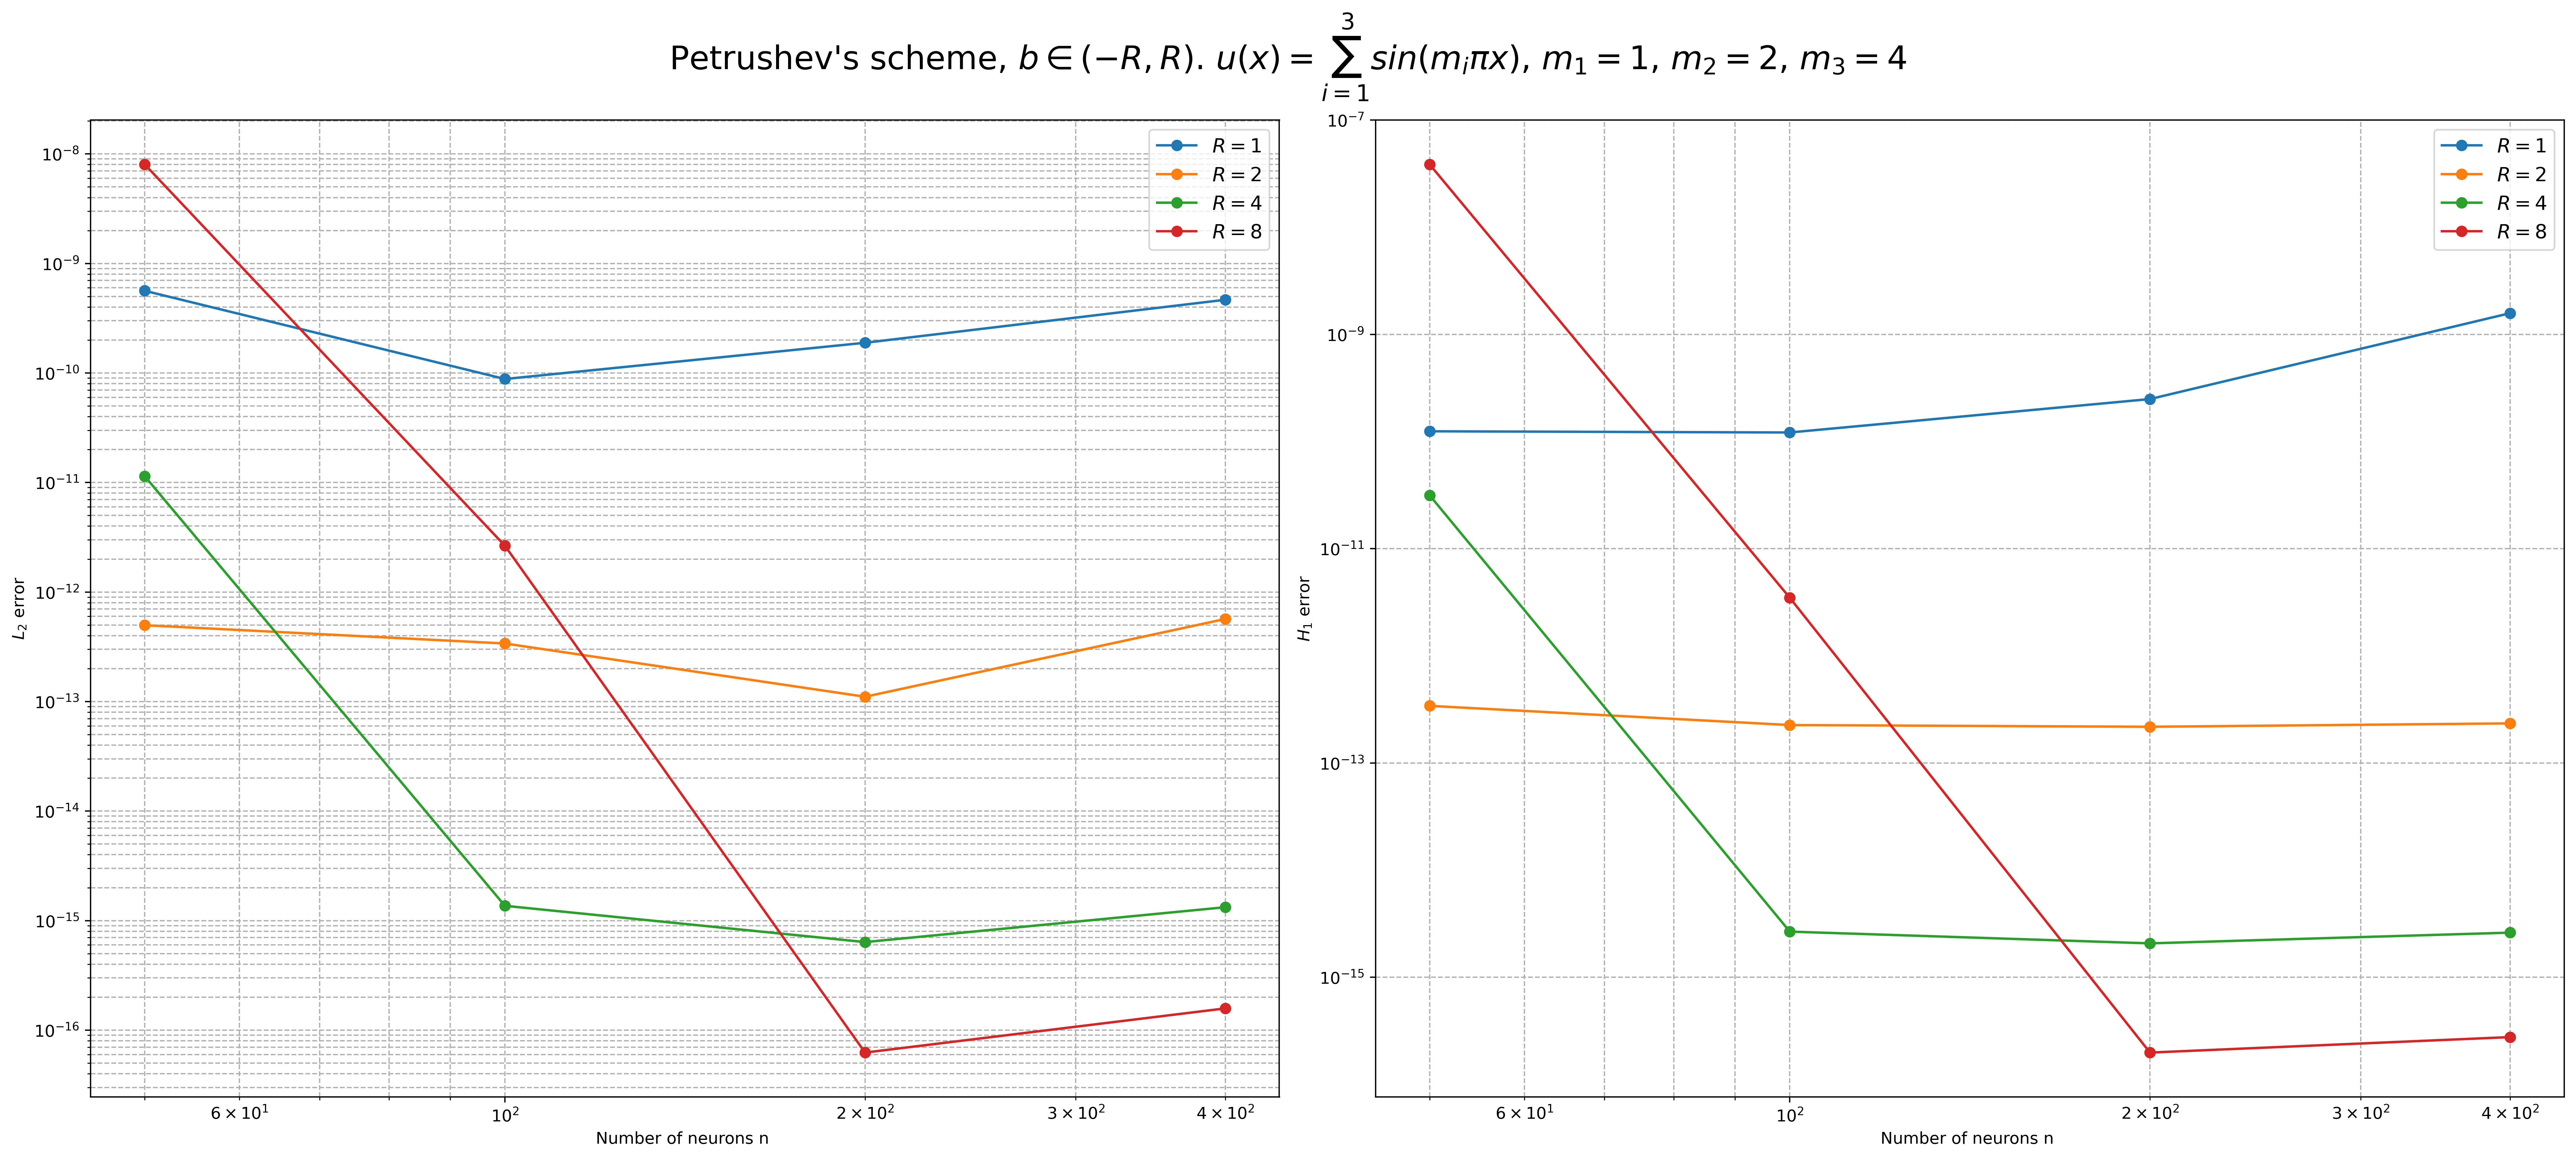

In [9]:
def main(m1, m2, m3):
    # m1, m2, m3 are kept just to preserve the interface; not used below.

    def u_exact(x, d):
        """
        u(x) = sin(10x)/100 - x * sin(10)/100
        """
        return torch.sin(10.0 * x) / 100.0 - x * torch.sin(torch.tensor(10.0)) / 100.0

    def f_rhs(x, d):
        r"""
        f(x) = -u''(x) = sin(10x)
        (d is not used anymore)
        """
        return torch.sin(10.0 * x)

    def u_exact_grad(d):
        r"""
        u'(x) = 0.1 * cos(10x)

        We keep the previous interface and return a list of
        gradient components. In 1D, it's just [u_x].
        """
        def u_x(x):
            return 0.1 * torch.cos(10.0 * x) - torch.sin(torch.tensor(10.0)) / 100.0

        return [u_x]

    # torch.manual_seed(1)
    # Problem and network parameters:
    d = 1         # spatial dimension (you can change this to, say, 10)
    input_dim = d # spatial
    activation = 'tanh'
    relu_k = 3 #if activation is tanh, this parameter is not used
    # neuron_list = [16,32,64,128,256] # 250,500,1000,2000,4000,8000]
    # neuron_list = [i for i in range(4,50,4)] 
    # neuron_list = [2**i for i in range(2,9)]
    neuron_list = [50,100,200,400]
    actual_neuron_list = torch.zeros(len(neuron_list))

    errors_l2 = torch.zeros(len(neuron_list))
    Nx = 1024 
    order = 5 
    x_l, x_r = 0, 1
    integration_weights, integration_points = PiecewiseGQ1D_weights_points(x_l,x_r,Nx,order)
    fig, axes = plt.subplots(1, 2, figsize=(11*2, 10), dpi=400)  
    for Rm in [1,2,4,8]: # 1e-2,5e-2,1e-1,5e-1,1,2,4 
        print('Activation: {}, relu_k: {}, Rm: {}'.format(activation,relu_k,Rm))
        trial_num = 1 
        errors_l2_trials = torch.zeros(trial_num, len(neuron_list)) 
        errors_h1_trials = torch.zeros(trial_num, len(neuron_list)) 
        for i, n in enumerate(neuron_list): # number of hidden units in the ELM

            for trial in range(trial_num):  
                
                # Number of collocation points
                N_bc = 1 #int(0.2 * n**1.5) # 160       # per boundary face (for Dirichlet BC)
                N_init = 4000 #int( 4 * n**1.5) # 1000    # initial condition points (at t = 0)
                # print("boundary points: ",N_bc*2*d)
                # print("interior points: ",N_init) 
                # print("total points: ",N_bc*2*d + N_init)
                # Generate collocation points:
                X_bc = generate_boundary_points(N_bc, d,x_l,x_r)     # boundary points on ∂Ω × [0, T]
                X_init = generate_initial_points(N_init, d,x_l,x_r)     # initial points: Ω at t = 0
                # X_init = integration_points
                integration_weights = torch.ones(X_init.size(), device=device)
                # Compute the right-hand side f (for the PDE) at interior points:
                f_in = f_rhs(X_init, d)   # shape: (N_in, 1)
                # For Dirichlet boundary condition, g(x, t) is given by u_exact:
                g_bc = u_exact(X_bc, d)
                # For initial condition, h(x) = u_exact(x, 0):

                # Create the ELM model:
                model = ELMModel(input_dim, n, activation, relu_k, Rm).to(device)
                # model.initialize_w_b_uniform_deterministic(R_m=Rm)
                # model.initialize_w_b_petrushev(R_m=Rm, scale=1)
                model.initialize_w_b_sphere(Rm) 
                actual_neuron_list[i] = model.b.size(0)
    #             # ----- Compute the design matrix for the PDE residual -----
                A_in, _ = compute_design_matrix_interior_manual(integration_weights, X_init, model, d)  # shape: (N_in, M)
                # For the boundary and initial points, the design matrix is just the hidden-layer outputs:
                A_bc = compute_design_matrix_boundary(X_bc, model) * integration_weights[0,0]      # shape: (N_bc_total, M)
                A_total = torch.cat([A_in,  A_bc], dim=0)  # (N_total, M) # Stack the design matrices and right-hand sides:
                b_total = torch.cat([f_in, g_bc], dim=0)    # (N_total, 1)

                A_total, b_total = rescale_mat_rhs(A_total,b_total)
                # ----- Solve for the output weights φ via least squares -----
                # We use the pseudo-inverse to compute: φ = pinv(A_total) @ b_total
                # phi_solution = torch.pinverse(A_total) @ b_total
                # phi_sol =  torch.linalg.lstsq(A_total,b_total).solution 
                phi_sol = scipy.linalg.lstsq(A_total.cpu().numpy(),b_total.cpu().numpy())[0]
                phi_sol = torch.from_numpy(phi_sol).to(device)
                model.phi.data.copy_(phi_sol.view(1,-1))

                # ------Evaluate the error ------
                Nx = 1024 
                order = 3
                integration_weights, integration_points = PiecewiseGQ1D_weights_points(x_l,x_r,Nx,order)
                u_exact_val = u_exact(integration_points, d) # shape: (M, 1) 
                diff_sqrd = (u_exact_val - model(integration_points))**2 
                errors_l2_trials[trial,i] = (integration_weights.t() @ diff_sqrd )**0.5
                u_exact_l2_norm = (integration_weights.t() @  u_exact_val**2 )**0.5

                u_exact_h1_norm = 0 # compute the error in H1 norm 
                u_grad = u_exact_grad(d)  

                for ii, grad_i in enumerate(u_grad):
                    u_pred_grad = model.evaluate_derivative(integration_points, ii+1)
                    u_exact_grad_val = grad_i(integration_points)
                    # print(u_pred_grad.size(),u_exact_grad_val.size()) 
                    squared_err = integration_weights.t()@ (u_pred_grad - u_exact_grad_val)**2 
                    errors_h1_trials[trial, i] += squared_err.item() # ith neuron numer 
                    u_exact_h1_norm += integration_weights.t()@ (u_exact_grad_val)**2 
                errors_h1_trials[trial, i]  = errors_h1_trials[trial, i] **0.5 
                u_exact_h1_norm = u_exact_h1_norm**0.5 

                # test accuracy
                x_grid = torch.linspace(x_l, x_r, 1002)[1:-1].view(-1, 1).to(device)
                u_exact_grid = u_exact(x_grid, d)
                u_pred_grid = model(x_grid)
                max_error = torch.max(torch.abs(u_exact_grid - u_pred_grid))
                rel_l2_error = (torch.sum((u_exact_grid - u_pred_grid)**2) / torch.sum(u_exact_grid**2))**0.5
                ave_pt_rel_error = torch.mean(torch.abs(u_exact_grid - u_pred_grid) / torch.abs(u_exact_grid + 1e-10))

        # mean errors 
        mean_errors_l2 = errors_l2_trials.mean(dim=0)
        mean_errors_h1 = errors_h1_trials.mean(dim=0)  
        print("L2 error {:.2e}; H1 error {:.2e} ".format(mean_errors_l2[i].item(), mean_errors_h1[i].item()) ) 
        print("L2 norm of u {}; H1 norm of u {} ".format(u_exact_l2_norm.item(), u_exact_h1_norm.item()) )
        print() 

        print("Max error on grid: {:.2e}".format(max_error.item()))
        print("Relative L2 error on grid: {:.2e}".format(rel_l2_error.item()))
        print("Average pointwise relative error on grid: {:.2e}".format(ave_pt_rel_error.item()))
        print()
        #print convergence orders 
        neuron_ratios = actual_neuron_list[1:]/actual_neuron_list[:-1]
        orders_mc_l2 = torch.log(mean_errors_l2[:-1] / mean_errors_l2[1:]) / torch.log(neuron_ratios) 
        orders_mc_h1 = torch.log(mean_errors_h1[:-1] / mean_errors_h1[1:]) / torch.log(neuron_ratios)
        print("thoeretical orders L^2: {}, H1: {} ".format(0.5 + (2*relu_k+1)/(2*d), 0.5 + (2*relu_k - 1)/(2*d)))
        print("Convergence orders (mc error L2):",orders_mc_l2)
        print("Convergence orders (mc error H1):",orders_mc_h1)

        # Plot the errors

        axes[0].loglog(actual_neuron_list, mean_errors_l2, 'o-', label=f"$R = {Rm}$") 
        axes[0].set_xlabel('Number of neurons n ')
        axes[0].set_ylabel('$L_2$ error') 
        axes[0].grid(True, which="both", ls="--") 
        axes[0].legend(fontsize=12)
        # axes[0].set_title('L2 error vs Number of neurons')

        axes[1].loglog(actual_neuron_list, mean_errors_h1, 'o-', label=f"$R = {Rm}$") 
        axes[1].set_xlabel('Number of neurons n ')
        axes[1].set_ylabel('$H_1$ error')
        axes[1].grid(True, which="both", ls="--") 
        axes[1].legend(fontsize=12)
        # axes[1].set_title('H1 error vs Number of neurons')

        fig.tight_layout()
        title = f"Petrushev's scheme, $b \in (-R, R)$. $u(x) = \sum_{{i=1}}^{3} sin(m_i \pi x)$, $m_1={m1}$, $m_2={m2}$, $m_3={m3}$"
        fig.suptitle(title,fontsize=20) 

    plt.show() 

if __name__ == '__main__':
    m1,m2,m3 = 1, 2, 4
    main(m1,m2,m3)

## 2D 

In [16]:
def generate_initial_points_uniform_grid(N, d,x_l = 0, x_r =1): # intial points are interior points 
    # Samples N points uniformly in Ω at t = 0 (initial condition)
    x = torch.linspace(x_l,x_r,N) 
    x1,x2 = torch.meshgrid(x,x,indexing='ij') 
    # print(x1)
    # print(x2)
    x1_int = x1[1:-1,1:-1]  
    x2_int = x2[1:-1,1:-1] 
    x_interior = torch.concat([x1_int.reshape(-1,1), x2_int.reshape(-1,1)], dim=1)  
    print(x_interior.size())  
    x1_bc = torch.cat([x1[:1,:].reshape(-1,1), x1[-1:,:].reshape(-1,1),x1[1:N-1,0:1].reshape(-1,1),x1[1:N-1,-1:].reshape(-1,1)], dim=0)  
    x2_bc = torch.cat([x2[:1,:].reshape(-1,1), x2[-1:,:].reshape(-1,1),x2[1:N-1,0:1].reshape(-1,1),x2[1:N-1,-1:].reshape(-1,1)], dim=0)  
    x_boundary = torch.concat([x1_bc.reshape(-1,1), x2_bc.reshape(-1,1)], dim=1)  
    return x_interior.to(device), x_boundary.to(device)  

a, b = generate_initial_points_uniform_grid(4, 2,x_l = 0, x_r =1)
print(a)
print() 
print(b) 

torch.Size([4, 2])
tensor([[0.3333, 0.3333],
        [0.3333, 0.6667],
        [0.6667, 0.3333],
        [0.6667, 0.6667]])

tensor([[0.0000, 0.0000],
        [0.0000, 0.3333],
        [0.0000, 0.6667],
        [0.0000, 1.0000],
        [1.0000, 0.0000],
        [1.0000, 0.3333],
        [1.0000, 0.6667],
        [1.0000, 1.0000],
        [0.3333, 0.0000],
        [0.6667, 0.0000],
        [0.3333, 1.0000],
        [0.6667, 1.0000]])


### tanh experiments 

In [ ]:

class ELMModel(nn.Module):
    def __init__(self, input_dim, M, activation, relu_k, Rm=0.1, remove_redundant=True, domain_choice=2):
        """
        Parameters:
            input_dim (int): Dimension of the input.
            M (int): Initial number of hidden neurons.
            activation (str): Activation function ('relu' or 'tanh').
            relu_k (int): For ReLU activation, the power to which it is raised.
            Rm (float): Range for weight and bias initialization.
            remove_redundant (bool): If True and using ReLU, remove redundant neurons.
            domain_choice (int): Choice for the domain points used in redundancy removal.
        """
        super(ELMModel, self).__init__()
        self.input_dim = input_dim
        self.M = M
        self.activation = activation
        self.k = relu_k
        
        # Define hidden-layer weights and biases as non-trainable parameters.
        self.W = nn.Parameter(torch.empty(M, input_dim).uniform_(-Rm, Rm), requires_grad=False)
        self.b = nn.Parameter(torch.empty(M).uniform_(-Rm, Rm), requires_grad=False)
        
        if self.activation == 'relu' and input_dim != 2:
            random_feature_sphere = torch.randn(M, input_dim + 1)
            random_feature_sphere = random_feature_sphere / torch.norm(random_feature_sphere, dim=1, keepdim=True)
            self.W.data = random_feature_sphere[:, :-1]
            self.b.data = random_feature_sphere[:, -1]
        if self.activation == 'relu' and input_dim == 2:
            neuron_nums = M
            indices = torch.arange(0, neuron_nums, dtype=torch.float) + 0.5
            phi = torch.acos(1 - 2*indices/neuron_nums)
            theta = pi * (1 + 5**0.5) * indices
            x = torch.sin(phi) * torch.cos(theta)
            y = torch.sin(phi) * torch.sin(theta)
            z = torch.cos(phi)
            points = torch.stack((x, y, z), dim=1)
            self.W.data[:,:] = points[:,0:2]
            self.b.data[:] = points[:,2]
        
        # Output weights φ
        self.phi = nn.Parameter(torch.zeros(1, M), requires_grad=False)
        
        if self.activation == 'relu' and remove_redundant:
            self.remove_redundant_neurons(dims=self.input_dim, choice=domain_choice)
    
    def hidden(self, x):
        if self.activation == 'tanh':
            return torch.tanh(x @ self.W.t() + self.b)
        elif self.activation == 'relu':
            return F.relu(x @ self.W.t() + self.b) ** self.k
            
    def forward(self, x):
        V = self.hidden(x)
        return V @ self.phi.t()
    
    def evaluate_derivative(self, x, i):
        if self.activation == 'tanh':
            fprime = 1 - torch.tanh(x @ self.W.t() + self.b) ** 2
            u1 = (fprime * self.W.t()[i-1:i, :]) @ self.phi.t()
        elif self.activation == 'relu':
            if self.k == 1:
                u1 = (torch.heaviside(x @ self.W.t() + self.b, torch.tensor(0.0)) * self.W.t()[i-1:i, :]) @ self.phi.t()
            else:
                u1 = (self.k * F.relu(x @ self.W.t() + self.b) ** (self.k - 1) * self.W.t()[i-1:i, :]) @ self.phi.t()
        return u1

    def remove_redundant_neurons(self, dims=3, choice=2):
        def create_mesh_grid(dims, pts):
            mesh = torch.tensor(list(itertools.product(pts, repeat=dims)), dtype=torch.float64)
            vertices = mesh.reshape(len(pts) ** dims, -1)
            return vertices
        
        if choice == 1:
            pts = torch.tensor([0., 1.])
        elif choice == 2:
            pts = torch.tensor([-1., 1.])
        elif choice == 3:
            pts = torch.tensor([-0.5, 0.5])
        else:
            raise ValueError("choice must be 1, 2, or 3")
        
        positions = create_mesh_grid(dims, pts)
        neuron_num = self.W.size(0)
        relu_k = self.k
        recorded_weights = []
        recorded_biases = []
        counter = 0
        poly_dofs = math.comb(relu_k + dims, dims)
        
        for i in range(neuron_num):
            w = self.W[i:i+1, :]
            b_val = self.b[i]
            values = positions @ w.t()
            left_end = - torch.max(values)
            right_end = - torch.min(values)
            offset = (right_end - left_end) / 50
            if b_val > left_end + offset/2 and b_val < right_end - offset/2:
                recorded_weights.append(w)
                recorded_biases.append(b_val)
            elif b_val >= right_end - offset/2 and counter < poly_dofs:
                recorded_weights.append(w)
                recorded_biases.append(b_val)
                counter += 1
        
        new_neuron_num = len(recorded_weights)
        if new_neuron_num == 0:
            print("Warning: No neurons selected; keeping all neurons.")
            return
        
        new_W = torch.cat(recorded_weights, dim=0)
        new_b = torch.stack(recorded_biases)
        self.M = new_neuron_num
        self.W = nn.Parameter(new_W, requires_grad=False)
        self.b = nn.Parameter(new_b, requires_grad=False)
        self.phi = nn.Parameter(torch.zeros(1, new_neuron_num), requires_grad=False)
        
        print("Number of neurons removed: ", neuron_num - new_neuron_num)
        print("Number of neurons left: ", new_neuron_num)

    def initialize_w_b_sphere(self,R_m):
        # generate a uniform grid on S^2 
        if self.input_dim == 2: 
            indices = torch.arange(0, self.M, dtype=torch.float64) + 0.5
            phi = torch.acos(1 - 2*indices/self.M)
            theta = pi * (1 + 5**0.5) * indices
            x = torch.sin(phi) * torch.cos(theta)
            y = torch.sin(phi) * torch.sin(theta)
            z = torch.cos(phi)

            points = torch.stack((x, y, z), dim=1)
            self.W = nn.Parameter(points[:,0:2] * R_m, requires_grad=False)
            self.b = nn.Parameter(points[:,2] * R_m, requires_grad=False)

        elif self.input_dim == 1:
            theta = torch.linspace(0, pi, self.M+1)[:-1]
            w1 = torch.cos(theta) * R_m
            b = torch.sin(theta) * R_m
            self.W = nn.Parameter(w1[:].view(-1,1), requires_grad=False)
            self.b = nn.Parameter(b[:], requires_grad=False)
        else: 
            w_b = torch.randn(self.M ,self.input_dim + 1) 
            w_b = w_b / torch.norm(w_b,dim=1).view(-1,1) 
            w_b = w_b * R_m 
            self.W = nn.Parameter(w_b[:,:-1], requires_grad=False)
            self.b = nn.Parameter(w_b[:,-1], requires_grad=False) 

    def initialize_w_b_uniform_deterministic(self, R_m):
        """
        Uniform and deterministic initialization for tanh ELMs.
        """
        if self.activation != "tanh":
            raise ValueError("initialize_w_b_uniform_deterministic() is intended for activation == 'tanh'.")

        x_grid = torch.linspace(-R_m, R_m, int(math.ceil(self.M ** (1 / (self.input_dim+1)))), device=self.W.device) # [:-1]
        if self.input_dim == 1:
            #2d grid 

            # h_half = (x_grid[1]-x_grid[0])/2 
            x_grid_shifted = x_grid # + h_half 
            x,y = torch.meshgrid(x_grid, x_grid_shifted, indexing='ij')
            weights = x.flatten().view(-1,1)
            biases = y.flatten()
        elif self.input_dim == 2:
            #3d grid 
            h_third = (x_grid[1]-x_grid[0])/3
            x_grid_shifted = x_grid #+ h_third
            x_grid_shifted2 = x_grid # + 2*h_third
            x,y,z = torch.meshgrid(x_grid, x_grid_shifted, x_grid_shifted2, indexing='ij')
            weights = torch.stack((x.flatten(),y.flatten()),dim=1)
            biases = z.flatten()
        else:
            # quasi monte carlo points
            raise NotImplementedError("Quasi Monte Carlo points not implemented.")

        new_M = weights.shape[0]

        with torch.no_grad():
            self.W = nn.Parameter(weights, requires_grad=False)
            self.b = nn.Parameter(biases, requires_grad=False)
            self.M = new_M
            self.phi = nn.Parameter(torch.zeros(1, new_M, device=device), requires_grad=False)

        return self


    def initialize_w_b_petrushev(my_model,R_m,radius = 1, scale = 1):
        w = my_model.fc1.weight
        b = my_model.fc1.bias
        out_feats, in_feats = w.shape
        device = w.device
        n1 = scale * math.ceil(out_feats**((in_feats - 1)/in_feats)) 
        n2 = math.ceil(out_feats**(1/in_feats))
        with torch.no_grad():
            if in_feats == 1:  #n by 1 
                weights = torch.ones(n1,1).to(device)
                # weights[:,0] = torch.linspace(-R_m,R_m,n1) 
            elif in_feats == 2:
                weights = torch.zeros(n1,2).to(device)
                theta = np.linspace(0,pi,n1,endpoint=False) 
                theta = torch.tensor(theta).to(device)
                weights[:, 0] = theta.cos()
                weights[:, 1] = theta.sin() 
                #form a tensor product of weights and biases
            elif in_feats == 3: 
                indices = torch.arange(0, n1, dtype=torch.float) + 0.5
                phi = torch.acos(1 - 2*indices/n1)
                theta = pi * (1 + 5**0.5) * indices
                x = torch.sin(phi) * torch.cos(theta)
                y = torch.sin(phi) * torch.sin(theta)
                z = torch.cos(phi)
                weights = torch.stack((x, y, z), dim=1)
            elif in_feats >= 4: 
                # nn.init.normal_(w, mean = 0, std = 1)
                weights = torch.randn(n1, in_feats).to(device) 
                weights = weights / torch.norm(weights,dim=1).view(-1,1) 

            # form a tensor product of weights and biases 
            weights = torch.tile(weights, (1,n2)).reshape(-1,in_feats) 
            # print("weights shape: ", weights.shape) 
            # print("nn w shape: ", w.shape)
            my_model = model_tanh(in_feats, n1*n2, 1).to(device) 
            biases = torch.linspace(-R_m,R_m,n2).to(device)
            # biases = torch.tensor(biases).to(device) 
            biases = torch.tile(biases, (n1,1)).reshape(-1) 
            # w[:,:] = weights[:out_feats,:] 
            my_model.fc1.weight.data[:,:] = weights[:,:] * radius 
            my_model.fc1.bias.data[:] = biases[:]  

        return my_model 

    def initialize_w_b_petrushev(self, r_1, r_2, scale=1):
        """
        Petrushev-style tensor-product initialization for tanh ELMs.
        """
        if self.activation != "tanh":
            raise ValueError("initialize_w_b_petrushev() is intended for activation == 'tanh'.")

        device = self.W.device
        in_feats = self.input_dim
        out_feats = self.M

        n1 = int(scale * math.ceil(out_feats ** ((in_feats - 1) / in_feats)))
        n2 = int(math.ceil(out_feats ** (1 / in_feats)))

        if in_feats == 1:
            weights = torch.ones(n1, 1, device=device)
        elif in_feats == 2:
            weights = torch.zeros(n1, 2, device=device)
            
            theta = torch.tensor(np.linspace(0, math.pi, n1, endpoint=False), device=device, dtype=weights.dtype)
            weights[:, 0] = torch.cos(theta)
            weights[:, 1] = torch.sin(theta)
        elif in_feats == 3:
            indices = torch.arange(0, n1, dtype=torch.float32, device=device) + 0.5
            phi = torch.acos(1 - 2 * indices / n1)
            theta = math.pi * (1 + 5 ** 0.5) * indices
            x = torch.sin(phi) * torch.cos(theta)
            y = torch.sin(phi) * torch.sin(theta)
            z = torch.cos(phi)
            weights = torch.stack((x, y, z), dim=1)
        else:
            weights = torch.randn(n1, in_feats, device=device)
            weights = weights / (weights.norm(dim=1, keepdim=True) + 1e-12)

        weights = torch.tile(weights, (1, n2)).reshape(-1, in_feats) 

        biases = torch.linspace(-r_2, r_2, n2, device=device)
        biases = torch.tile(biases, (n1,)).reshape(-1)

        new_M = weights.shape[0]

        with torch.no_grad():
            self.W = nn.Parameter(weights* r_1, requires_grad=False)
            self.b = nn.Parameter(biases, requires_grad=False)
            self.M = new_M
            self.phi = nn.Parameter(torch.zeros(1, new_M, device=device), requires_grad=False)

        return self

def plot_2D(f): 
    
    Nx = 200
    Ny = 200 
    xs = np.linspace(-1, 1, Nx)
    ys = np.linspace(-1, 1, Ny)
    x, y = np.meshgrid(xs, ys, indexing='xy')
    xy_comb = np.stack((x.flatten(),y.flatten())).T
    xy_comb = torch.tensor(xy_comb)
    z = f(xy_comb).reshape(Nx,Ny)
    z = z.detach().numpy()
    plt.figure(dpi=200)
    ax = plt.axes(projection='3d')
    ax.plot_surface(x , y , z )

    plt.show()

torch.float64


Activation: tanh, relu_k: 3, Rm: 2
torch.Size([9604, 2])
torch.Size([9604, 2])
torch.Size([9604, 2])
torch.Size([9604, 2])
torch.Size([9604, 2])
torch.Size([9604, 2])
torch.Size([9604, 2])
torch.Size([9604, 2])
thoeretical orders L^2: 2.25, H1: 1.75 
Convergence orders (mc error L2): tensor([0.2226,    nan, 0.9457, 1.9612, 1.3721, 4.9087, 1.5032])
Convergence orders (mc error H1): tensor([-1.0218,     nan,  0.4473,  1.4181,  0.8823,  4.4041,  1.1202])
L2 error  tensor([3.5439e+00, 3.1178e+00, 3.1178e+00, 9.4950e-01, 3.7568e-01, 2.2239e-01,
        2.0896e-03, 1.0179e-03])
H1 error  tensor([18.3939, 33.1125, 33.1125, 18.8696,  9.6515,  6.8894,  0.1046,  0.0612])
Activation: tanh, relu_k: 3, Rm: 4
torch.Size([9604, 2])
torch.Size([9604, 2])
torch.Size([9604, 2])
torch.Size([9604, 2])
torch.Size([9604, 2])
torch.Size([9604, 2])
torch.Size([9604, 2])
torch.Size([9604, 2])
thoeretical orders L^2: 2.25, H1: 1.75 
Convergence orders (mc error L2): tensor([ 0.2867,     nan,  1.5447,  8.6369, 1

/var/folders/45/p1_q2drx75983lk7ph_1gx6mhpr5_w/T/ipykernel_50573/3324731521.py:167: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


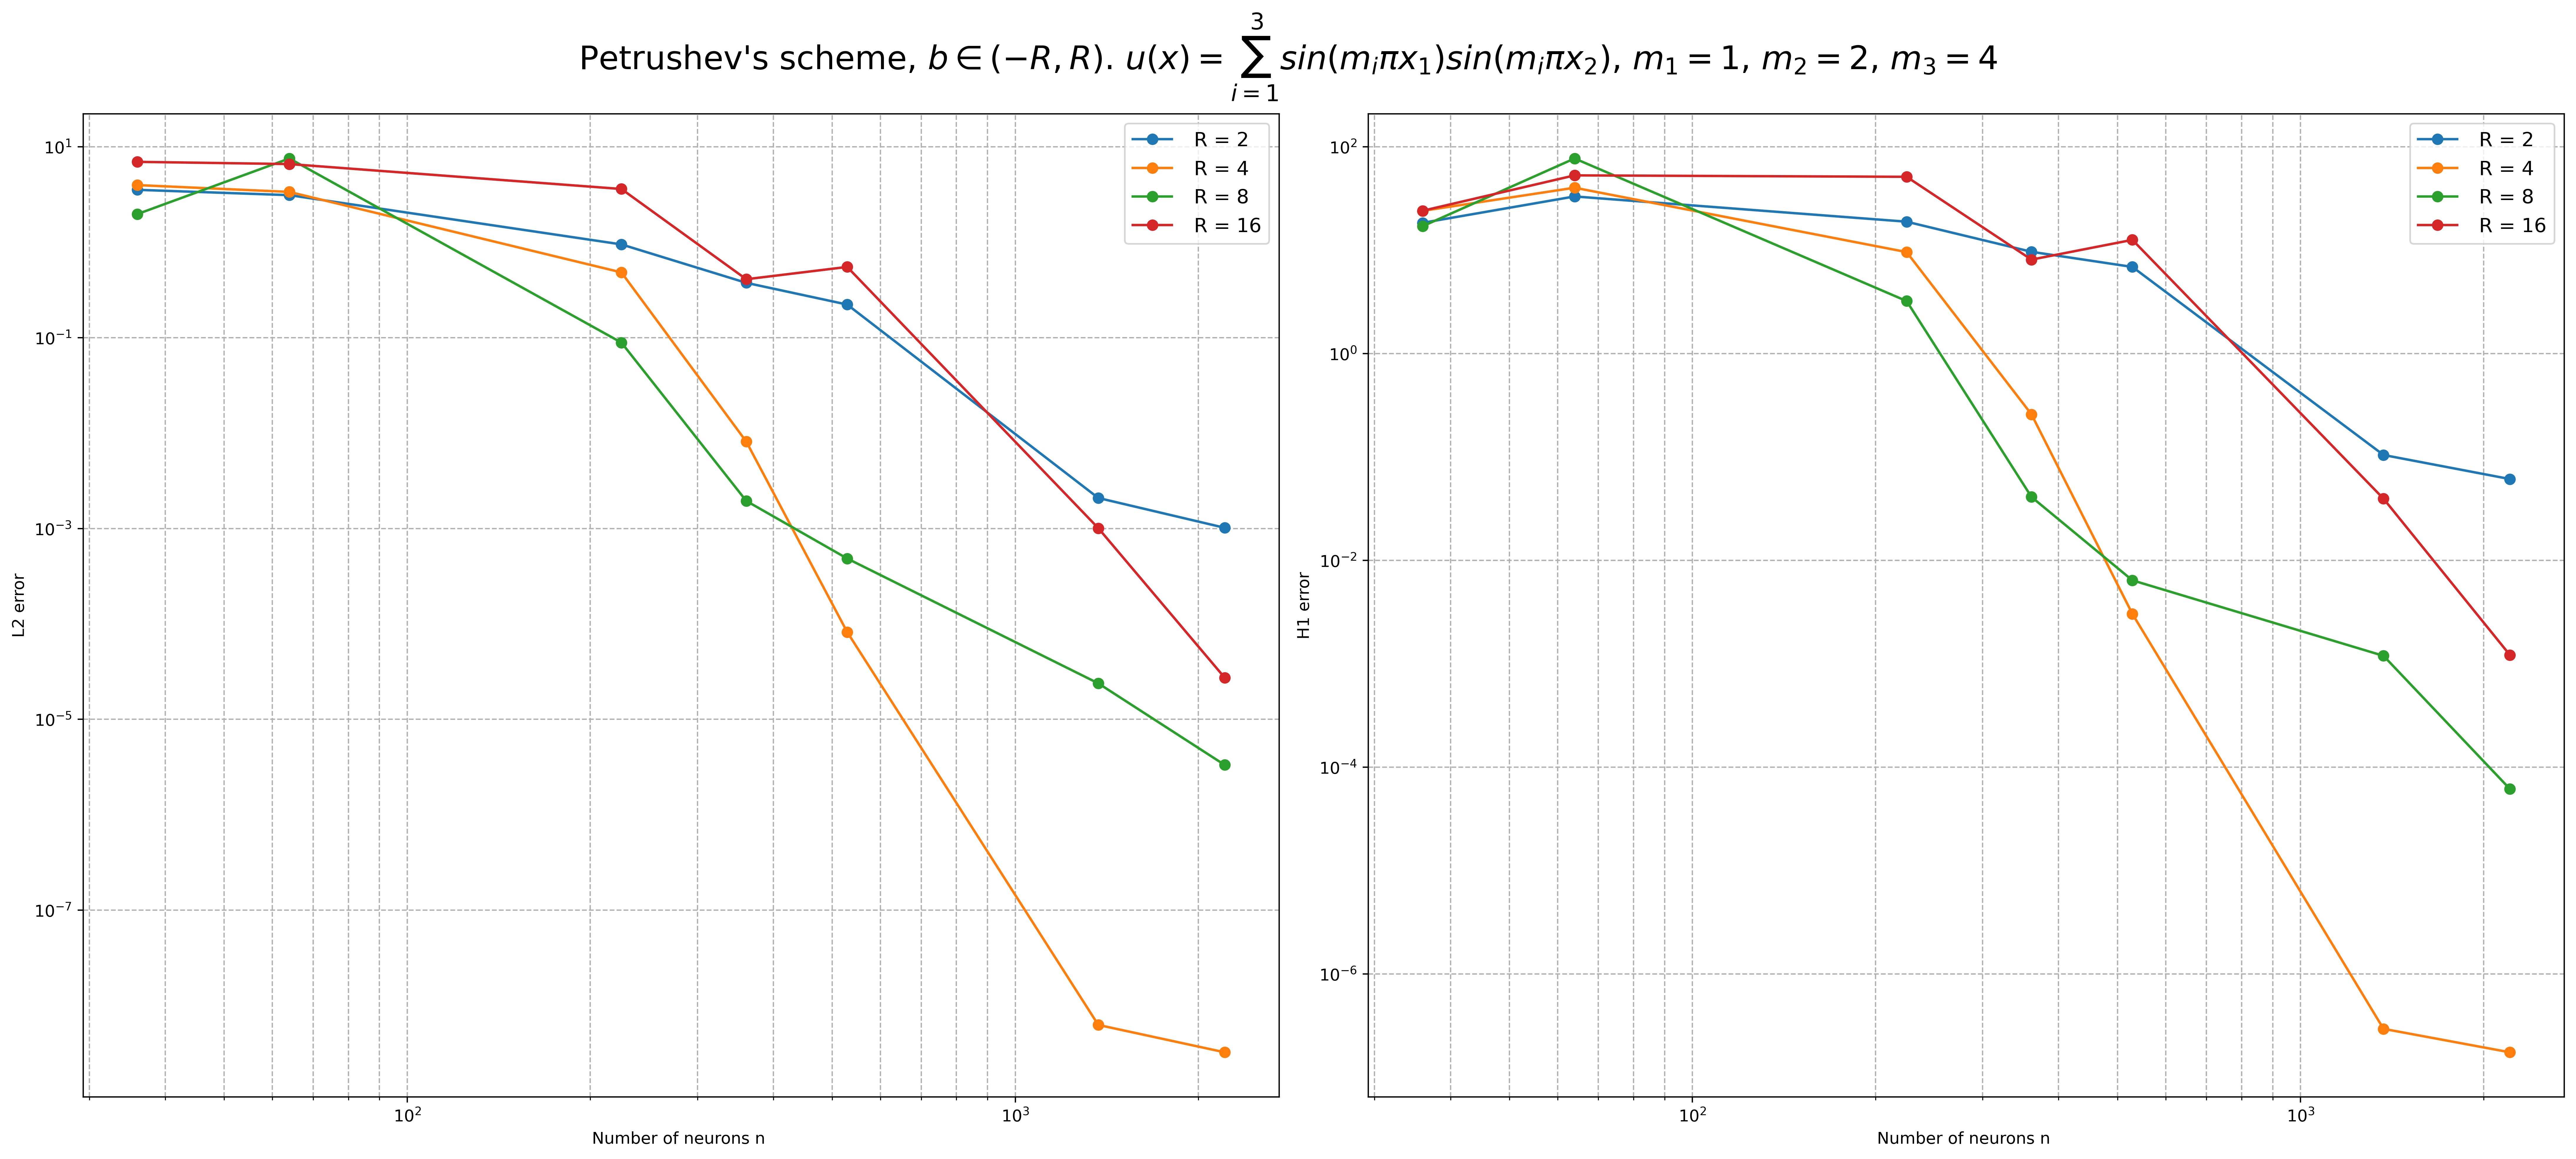

In [37]:
# ---------------------------
# Optiion 1: Exact solution and forcing function 
# ---------------------------
A1 = 1  
m1 = 1
A2 = 1
m2 = 2
A3 = 1 
m3 = 4 
def u_exact(x,d):
    z1 = A1*torch.prod(torch.sin(m1* pi * x),dim = 1,keepdim = True) 
    z2 = A2*torch.prod(torch.sin(m2* pi * x),dim = 1,keepdim = True)
    z3 = A3*torch.prod(torch.sin(m3* pi * x),dim = 1,keepdim = True)
    return z1 + z2 + z3

def f_rhs(x,d):
    z1 = (d * (m1 * pi)**2 + 1)*A1 * torch.prod(torch.sin(m1 * pi * x),dim = 1,keepdim = True) 
    z2 = (d * (m2 * pi)**2 + 1)*A2*torch.prod(torch.sin(m2 * pi * x),dim = 1,keepdim = True)
    z3 = (d * (m3 * pi)**2 + 1)*A3*torch.prod(torch.sin(m3 * pi * x),dim = 1,keepdim = True) 
    return z1 + z2 + z3

def u_exact_grad(d):
    dim = d # d is global variable defined outside the function 
    grad_list = [] 
    def make_u_i(i):
        def u_i(x): 
            sin_terms = torch.sin(m1 * pi * x)
            cos_term = torch.cos(m1 * pi * x[:, i-1:i])
            sin_terms[:, i-1:i] = cos_term  # Replace the first sine term with the cosine term
            sin_terms2 = A2*torch.sin(m2 * pi * x)
            cos_term2 = torch.cos(m2 * pi * x[:, i-1:i])
            sin_terms2[:, i-1:i] = cos_term2  # Replace the first sine term with the cosine term
            sin_terms3 = A3*torch.sin(m3 * pi * x)
            cos_term3 = torch.cos(m3 * pi * x[:, i-1:i])
            sin_terms3[:, i-1:i] = cos_term3  # Replace the first sine term with the cosine term
            z1 = (m1 * pi) * A1 * torch.prod(sin_terms, dim=1, keepdim=True) 
            z2 = (m2 * pi) * A2 * torch.prod(sin_terms2, dim=1, keepdim=True) 
            z3 = (m3 * pi) * A3 * torch.prod(sin_terms3, dim=1, keepdim=True)
            return z1 + z2 + z3
        return u_i 
    for i in range(1,dim+1):
        grad_list.append(make_u_i(i))
    return grad_list

def main():
    # torch.manual_seed(1)
    # Problem and network parameters:
    save = True 
    rand = False  # whether to use random initialization or deterministic one over [-R,R]
    d = 2          # spatial dimension (you can change this to, say, 10)
    input_dim = d # spatial
    activation = 'tanh'
    relu_k = 3 #if activation is tanh, this parameter is not used
    neuron_list = [2**i for i in range(4,12)]
    
    # integration_weights, integration_points = PiecewiseGQ2D_weights_points(Nx,order,(-1,-1),(1,1))
    x_l= 0
    x_r = 1
    fig, axes = plt.subplots(1, 2, figsize=(11*2, 10), dpi=400) 
    for Rm in [2,4,8,16]: # 1e-2,5e-2,1e-1,5e-1,1,2,4
        print('Activation: {}, relu_k: {}, Rm: {}'.format(activation,relu_k,Rm))
        trial_num = 1 
        errors_l2_trials = torch.zeros(trial_num, len(neuron_list)) 
        errors_h1_trials = torch.zeros(trial_num, len(neuron_list)) 
        actual_neuron_list = torch.zeros(trial_num,len(neuron_list))
        for i, n in enumerate(neuron_list): # number of hidden units in the ELM

            for trial in range(trial_num):  
                
                # Number of collocation points
                N_bc = 200 #int(0.2 * n**1.5) # 160       # per boundary face (for Dirichlet BC)
                N_init = 100 #int( 4 * n**1.5) # 1000    # initial condition points (at t = 0)

                X_init, X_bc = generate_initial_points_uniform_grid(N_init, d,x_l,x_r)

                integration_weights = torch.ones(X_init.size(0), device=device).view(-1,1) 

                # Compute the right-hand side f (for the PDE) at interior points:
                f_in = f_rhs(X_init, d)   # shape: (N_in, 1)
                # For Dirichlet boundary condition, g(x, t) is given by u_exact:
                g_bc = u_exact(X_bc, d)

                # Create the ELM model:
                model = ELMModel(input_dim, n, activation, relu_k, Rm).to(device)
                if rand != True: 
                    model.initialize_w_b_uniform_deterministic(R_m=Rm)
                model.initialize_w_b_petrushev(r_1 = 4, r_2 = Rm, scale=1)  
                # model.initialize_w_b_sphere(Rm)  

                actual_neuron_list[trial, i] = model.b.size(0)
    #             # ----- Compute the design matrix for the PDE residual -----
                A_in, _ = compute_design_matrix_interior_manual(integration_weights, X_init, model, d)  # shape: (N_in, M)
                # For the boundary and initial points, the design matrix is just the hidden-layer outputs:
                A_bc = compute_design_matrix_boundary(X_bc, model) # * integration_weights[0,0]      # shape: (N_bc_total, M)
                A_total = torch.cat([A_in,  A_bc], dim=0)  # (N_total, M) # Stack the design matrices and right-hand sides:
                b_total = torch.cat([f_in, g_bc], dim=0)    # (N_total, 1)

                A_total, b_total = rescale_mat_rhs(A_total,b_total) 
                # ----- Solve for the output weights φ via least squares -----
                # We use the pseudo-inverse to compute: φ = pinv(A_total) @ b_total
                # phi_solution = torch.pinverse(A_total) @ b_total
                # phi_sol =  torch.linalg.lstsq(A_total,b_total).solution 
                phi_sol = scipy.linalg.lstsq(A_total.cpu().numpy(),b_total.cpu().numpy())[0]
                phi_sol = torch.from_numpy(phi_sol).to(device) 
                model.phi.data.copy_(phi_sol.view(1,-1))

                # ------Evaluate the error ------
                Nx = 20
                order = 3 
                integration_weights, integration_points = PiecewiseGQ2D_weights_points(Nx,order,(x_l,x_l),(x_r,x_r))
                u_exact_val = u_exact(integration_points, d) # shape: (M, 1) 
                diff_sqrd = (u_exact_val - model(integration_points))**2 
                errors_l2_trials[trial,i] = (integration_weights.t() @ diff_sqrd )**0.5
                u_exact_l2_norm = (integration_weights.t() @  u_exact_val**2 )**0.5

                u_exact_h1_norm = 0 # compute the error in H1 norm 
                u_grad = u_exact_grad(d)  
                for ii, grad_i in enumerate(u_grad):
                    u_pred_grad = model.evaluate_derivative(integration_points, ii+1)
                    u_exact_grad_val = grad_i(integration_points)
                    # print(u_pred_grad.size(),u_exact_grad_val.size()) 
                    squared_err = integration_weights.t()@ (u_pred_grad - u_exact_grad_val)**2 
                    errors_h1_trials[trial, i] += squared_err.item() # ith neuron numer 
                    u_exact_h1_norm += integration_weights.t()@ (u_exact_grad_val)**2 
                errors_h1_trials[trial, i]  = errors_h1_trials[trial, i] **0.5 
                u_exact_h1_norm = u_exact_h1_norm**0.5 
            
        # mean errors 
        mean_errors_l2 = errors_l2_trials.mean(dim=0)
        mean_errors_h1 = errors_h1_trials.mean(dim=0)  
        mean_actual_neuron_list = actual_neuron_list.mean(dim=0)

        if save == True: 
            foldername = "data-compare-rand/"
            torch.save(mean_errors_l2, foldername + 'l2err_ELM_rand_{}_2D_act{}_R{}_m{}_{}_{}.pt'.format(rand,activation,Rm,m1,m2,m3))
            torch.save(mean_errors_h1, foldername + 'H1err_ELM_rand_{}_2D_act{}_R{}_m{}_{}_{}.pt'.format(rand, activation,Rm,m1,m2,m3))
            torch.save(mean_actual_neuron_list, foldername + 'neuronlist_ELM_rand_{}_2D_act{}_R{}_m{}_{}_{}.pt'.format(rand, activation,Rm,m1,m2,m3))
        
        #print convergence orders 
        neuron_ratios = mean_actual_neuron_list[1:]/mean_actual_neuron_list[:-1]
        orders_mc_l2 = torch.log(mean_errors_l2[:-1] / mean_errors_l2[1:]) / torch.log(neuron_ratios) 
        orders_mc_h1 = torch.log(mean_errors_h1[:-1] / mean_errors_h1[1:]) / torch.log(neuron_ratios)
        print("thoeretical orders L^2: {}, H1: {} ".format(0.5 + (2*relu_k+1)/(2*d), 0.5 + (2*relu_k - 1)/(2*d)))
        print("Convergence orders (mc error L2):",orders_mc_l2)
        print("Convergence orders (mc error H1):",orders_mc_h1)
        print("L2 error ",mean_errors_l2)
        print("H1 error ",mean_errors_h1)
        # Plot the errors
        # plt.figure(figsize=(10, 6))
        
        axes[0].loglog(mean_actual_neuron_list, mean_errors_l2, 'o-', label=f' R = {Rm}') 
        axes[0].set_xlabel('Number of neurons n ')
        axes[0].set_ylabel('L2 error') 
        axes[0].grid(True, which="both", ls="--") 
        axes[0].legend(fontsize=12)

        axes[1].loglog(mean_actual_neuron_list, mean_errors_h1, 'o-', label=f' R = {Rm}') 
        axes[1].set_xlabel('Number of neurons n ')
        axes[1].set_ylabel('H1 error')
        axes[1].grid(True, which="both", ls="--") 
        axes[1].legend(fontsize=12)

        fig.tight_layout()
        title = f"Petrushev's scheme, $b \in (-R, R)$. $u(x) = \sum_{{i=1}}^{3} sin(m_i \pi x_1)sin(m_i \pi x_2)$, $m_1={m1}$, $m_2={m2}$, $m_3={m3}$"
        # title = f"Petrushev's scheme, $b \in (-R, R)$. $u(x) = \sum_{{i=1}}^{2} sin(m_i \pi x_1)sin(m_i \pi x_2)$, $m_1={m1}$, $m_2={m2}$"
        fig.suptitle(title,fontsize=20) 
    fig.show() 

if __name__ == '__main__':
    main()